## Terrorism Attack Analysis

# 🌍Global Terrorism Analysis (1970–2017)
**UN Global Terrorism Analysis | EDA · Missing Values · Outliers · Visualisations · Insights**

Contribution - Individual(Ishika)


# Project Summary -

PROJECT SUMMARY

Terrorism is one of the most pressing global security concerns of the modern world. The Global Terrorism Database (GTD) is an open-source database maintained by the National Consortium for the Study of Terrorism and Responses to Terrorism (START) at the University of Maryland. It contains information on over 180,000 terrorist attacks worldwide from 1970 through 2017, making it the most comprehensive unclassified database on terrorist events in the world.

This project conducts an in-depth Exploratory Data Analysis (EDA) on the Global Terrorism Dataset to uncover hidden patterns, temporal trends, geographical hotspots, and the devastating human cost of terrorist activities. By leveraging Python's powerful data analysis and visualization libraries, we systematically explore the dataset using the UBM rule — Univariate, Bivariate, and Multivariate analysis.

The analysis covers a wide range of dimensions including: which countries and regions have been most affected, which terrorist groups have been most active, what attack types and weapon types are most commonly used, how terrorism has evolved over decades, and what the resulting casualties look like across different categories.

Key goals of this analysis include:
- Identifying global hotspots of terrorist activity over time.
- Understanding the most prolific terrorist organizations worldwide.
- Analyzing preferred attack types, target types, and weapon categories.
- Studying trends in casualties (killed and wounded) across regions and time.
- Deriving actionable business and policy insights that could help governments, NGOs, security firms, and researchers make informed decisions.

The insights from this EDA can support counter-terrorism policy formulation, risk assessment for international businesses, humanitarian aid allocation, and academic research on conflict patterns. The project follows a structured, production-grade coding style with proper exception handling and clear commentary throughout.


# Github link

GITHUB LINK- https://github.com/ishikarana968

# Problem Statement

PROBLEM STATEMENT

Terrorist attacks have caused immeasurable human suffering, economic damage, and political instability across the globe. Despite decades of counter-terrorism efforts, attacks continue to evolve in frequency, method, and geography. There is a critical need to analyze historical terrorism data to understand patterns, identify high-risk regions and groups, and derive insights that can support proactive security measures and policy decisions.

**This project aims to answer:**
1. Which regions and countries are most affected by terrorism?
2. How has terrorism changed over the decades?
3. Which attack types and weapon types are most lethal?
4. Which terrorist organizations are most active and dangerous?
5. What are the primary targets of terrorist attacks?



# General Gudlines

BUSINESS OBJECTIVES-

The primary business objective is to provide a **data-driven intelligence report** on global terrorism trends that can be used by:
- **Governments & Security Agencies**: To allocate resources and preemptively address high-risk zones.
- **International Corporations**: To assess geo-political risk before establishing operations in specific regions.
- **Insurance Companies**: To price political risk insurance products accurately.
- **NGOs & Humanitarian Organizations**: To plan aid operations and prioritize conflict zones.
- **Academic Researchers**: To study conflict escalation patterns and radicalization trends.

**Success Metric**: Generating at least 20 actionable insights backed by visualizations that reveal meaningful patterns in global terrorism data.

# Let Begin

# Know your data

# Import Libaries

In [3]:
# §0 — Install dependencies (run once)
!pip install pandas numpy matplotlib seaborn plotly -q


In [4]:
# §1 — Imports & Style
import sys, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

IN_COLAB = "google.colab" in sys.modules

PALETTE    = ["#e63946","#f4a261","#2a9d8f","#457b9d","#6d6875","#264653","#e9c46a","#a8dadc"]
BG_COLOR   = "#0d1117"
TEXT_COLOR = "#f0f6fc"

plt.rcParams.update({
    "figure.facecolor":"#0d1117","axes.facecolor":"#161b22","axes.edgecolor":"#30363d",
    "axes.labelcolor":TEXT_COLOR,"xtick.color":TEXT_COLOR,"ytick.color":TEXT_COLOR,
    "text.color":TEXT_COLOR,"grid.color":"#21262d","grid.linestyle":"--","grid.alpha":0.5,
    "font.family":"DejaVu Sans","axes.titlesize":14,"axes.labelsize":11,
    "legend.facecolor":"#161b22","legend.edgecolor":"#30363d",
})
print("Libraries loaded ✓")


Libraries loaded ✓


# Dataset loading

In [5]:
# §2 — Load Data
def load_data(path=None):
    if path and os.path.exists(path):
        df = pd.read_csv(path, encoding="latin-1", low_memory=False)
        print(f"Loaded: {path} | {df.shape[0]:,} rows × {df.shape[1]} cols")
        return df
    if IN_COLAB:
        from google.colab import files
        print("⬆  Upload the GTD CSV file:")
        uploaded = files.upload()
        fname = list(uploaded.keys())[0]
        df = pd.read_csv(fname, encoding="latin-1", low_memory=False)
        print(f"Loaded '{fname}' | {df.shape[0]:,} rows × {df.shape[1]} cols")
        return df
    raise FileNotFoundError("Pass path= or run in Colab to upload.")

df_raw = load_data()


⬆  Upload the GTD CSV file:


Saving Global Terrorism Data.csv to Global Terrorism Data.csv
Loaded 'Global Terrorism Data.csv' | 181,691 rows × 135 cols


# Dataset First view

In [6]:
# §3 — Column Selection & Rename
COLS = {
    "iyear":"year","imonth":"month","iday":"day",
    "country_txt":"country","region_txt":"region","city":"city",
    "latitude":"latitude","longitude":"longitude",
    "attacktype1_txt":"attack_type","targtype1_txt":"target_type",
    "weaptype1_txt":"weapon_type","gname":"group_name",
    "nkill":"killed","nwound":"wounded",
    "success":"success","suicide":"suicide",
    "property":"property_damage","propvalue":"property_value",
}
available = {k:v for k,v in COLS.items() if k in df_raw.columns}
df = df_raw[list(available.keys())].rename(columns=available).copy()
print(f"Working shape: {df.shape}")
df.head(3)


Working shape: (181691, 18)


,year,month,day,country,region,city,latitude,longitude,attack_type,target_type,weapon_type,group_name,killed,wounded,success,suicide,property_damage,property_value
0,1970,7,2,Dominican Republic,Central America & Caribbean,Santo Domingo,18.456792,-69.951164,Assassination,Private Citizens & Property,Unknown,MANO-D,1.0,0.0,1,0,0,NaN
1,1970,0,0,Mexico,North America,Mexico city,19.371887,-99.086624,Hostage Taking (Kidnapping),Government (Diplomatic),Unknown,23rd of September Communist League,0.0,0.0,1,0,0,NaN
2,1970,1,0,Philippines,Southeast Asia,Unknown,15.478598,120.599741,Assassination,Journalists & Media,Unknown,Unknown,1.0,0.0,1,0,0,NaN


# Dataset information

In [7]:
# §4 — Data Exploration
print("=== dtypes ===")
print(df.dtypes)
print("\n=== describe (numeric) ===")
df.describe()


=== dtypes ===
year                 int64
month                int64
day                  int64
country             object
region              object
city                object
latitude           float64
longitude          float64
attack_type         object
target_type         object
weapon_type         object
group_name          object
killed             float64
wounded            float64
success              int64
suicide              int64
property_damage      int64
property_value     float64
dtype: object

=== describe (numeric) ===


,year,month,day,latitude,longitude,killed,wounded,success,suicide,property_damage,property_value
count,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,171378.000000,165380.000000,181691.000000,181691.000000,181691.000000,3.898900e+04
mean,2002.638997,6.467277,15.505644,23.498343,-4.586957e+02,2.403272,3.167668,0.889598,0.036507,-0.544556,2.088119e+05
std,13.259430,3.388303,8.814045,18.569242,2.047790e+05,11.545741,35.949392,0.313391,0.187549,3.122889,1.552463e+07
min,1970.000000,0.000000,0.000000,-53.154613,-8.618590e+07,0.000000,0.000000,0.000000,0.000000,-9.000000,-9.900000e+01
25%,1991.000000,4.000000,8.000000,11.510046,4.545640e+00,0.000000,0.000000,1.000000,0.000000,0.000000,-9.900000e+01
50%,2009.000000,6.000000,15.000000,31.467463,4.324651e+01,0.000000,0.000000,1.000000,0.000000,1.000000,-9.900000e+01
75%,2014.000000,9.000000,23.000000,34.685087,6.871033e+01,2.000000,2.000000,1.000000,0.000000,1.000000,1.000000e+03
max,2017.000000,12.000000,31.000000,74.633553,1.793667e+02,1570.000000,8191.000000,1.000000,1.000000,1.000000,2.700000e+09


# Dataset rows and columns count

In [8]:
# Value counts for key categoricals
for col in ["region","attack_type","weapon_type","target_type"]:
    if col in df.columns:
        print(f"\n── Top 10 [{col}] ──")
        print(df[col].value_counts().head(10))



── Top 10 [region] ──
region
Middle East & North Africa     50474
South Asia                     44974
South America                  18978
Sub-Saharan Africa             17550
Western Europe                 16639
Southeast Asia                 12485
Central America & Caribbean    10344
Eastern Europe                  5144
North America                   3456
East Asia                        802
Name: count, dtype: int64

── Top 10 [attack_type] ──
attack_type
Bombing/Explosion                      88255
Armed Assault                          42669
Assassination                          19312
Hostage Taking (Kidnapping)            11158
Facility/Infrastructure Attack         10356
Unknown                                 7276
Unarmed Assault                         1015
Hostage Taking (Barricade Incident)      991
Hijacking                                659
Name: count, dtype: int64

── Top 10 [weapon_type] ──
weapon_type
Explosives                                                     

# Missing and Duplicate values

In [9]:
# §5 — Missing Value Analysis
miss = (df.isnull().sum().reset_index()
         .rename(columns={"index":"column",0:"missing"}))
miss["pct"] = (miss["missing"]/len(df)*100).round(2)
miss = miss[miss["missing"]>0].sort_values("pct",ascending=False)
print(miss.to_string(index=False))


        column  missing   pct
property_value   142702 78.54
       wounded    16311  8.98
        killed    10313  5.68
      latitude     4556  2.51
     longitude     4557  2.51
          city      435  0.24


In [10]:
# §6 — Missing Value Treatment
HIGH_MISS = 60.0
high_miss_cols = miss[miss["pct"]>=HIGH_MISS]["column"].tolist()
print("Dropping:", high_miss_cols)
df.drop(columns=[c for c in high_miss_cols if c in df.columns], inplace=True)

df[["killed","wounded"]] = df[["killed","wounded"]].fillna(0) if all(c in df.columns for c in ["killed","wounded"]) else df.get(["killed","wounded"],pd.DataFrame()).fillna(0)

for coord in ["latitude","longitude"]:
    if coord in df.columns:
        df[coord] = df.groupby("country")[coord].transform(lambda x: x.fillna(x.median()))
        df[coord].fillna(df[coord].median(), inplace=True)

cat_cols = df.select_dtypes("object").columns.tolist()
df[cat_cols] = df[cat_cols].fillna("Unknown")
if "day" in df.columns: df["day"].replace(0,1,inplace=True)

print(f"Missing cells after cleaning: {df.isnull().sum().sum()}")


Dropping: ['property_value']
Missing cells after cleaning: 0


**What did you know about your dataset?**

The dataset is a high-volume, multi-dimensional terrorism incident table with rich temporal, geographic, operational, and impact fields. Initial checks show the data is suitable for EDA but requires careful preprocessing because many secondary attributes have substantial missingness. Core analytical columns such as year, country, region, primary attack type, primary target type, primary weapon type, and casualty counts are generally usable.


Date fields are split across year/month/day and include unknown placeholders (0 values) in some rows, so controlled date reconstruction is necessary. Duplicate record checks are included and should be resolved before trend analysis. Overall, this is a strong dataset for pattern discovery, provided we apply selective column retention, type corrections, missing-value handling, and outlier treatment for skewed casualty variables.

# Understanding our variables

In [11]:
# §7 — Feature Engineering
df["casualties"] = df["killed"].astype(float) + df["wounded"].astype(float)
df["decade"]     = (df["year"]//10*10).astype(str) + "s"
df["is_mass"]    = (df["casualties"]>=25).astype(int)
print("New cols: casualties, decade, is_mass ✓")


New cols: casualties, decade, is_mass ✓


In [12]:
# §8 — Outlier Detection & Capping (3×IQR)
for col in ["killed","wounded","casualties"]:
    if col not in df.columns: continue
    Q1,Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR   = Q3-Q1; upper = Q3+3*IQR
    print(f"{col}: IQR={IQR:.1f}, cap={upper:.0f}, outliers={(df[col]>upper).sum()}")
    df[f"{col}_capped"] = df[col].clip(upper=upper)


killed: IQR=2.0, cap=8, outliers=10235
wounded: IQR=2.0, cap=8, outliers=12738
casualties: IQR=4.0, cap=16, outliers=11612


**Variables Description**

Important variables used in this EDA include: iyear, imonth, iday (event timing), country_txt, region_txt, city (location), attacktype1_txt (attack method), targtype1_txt (target class), weaptype1_txt (weapon class), nkill and nwound (human impact), and success (attack outcome indicator).

These variables help answer strategic questions: where incidents are concentrated, how risk evolves, which attack modalities dominate, and what combinations produce higher casualties.

**Data** **Wrandling**

In [15]:
# Write your code to make your dataset analysis ready.
eda_cols = ['eventid','iyear','imonth','iday','country_txt','region_txt','city','attacktype1_txt','targtype1_txt','weaptype1_txt','nkill','nwound','success']
eda_df = df[eda_cols].copy()
eda_df = eda_df.drop_duplicates()
eda_df['imonth'] = eda_df['imonth'].replace(0, 1)
eda_df['iday'] = eda_df['iday'].replace(0, 1)
eda_df['event_date'] = pd.to_datetime(eda_df['iyear'].astype(str) + '-' + eda_df['imonth'].astype(int).astype(str) + '-' + eda_df['iday'].astype(int).astype(str), errors='coerce')
for c in ['country_txt','region_txt','city','attacktype1_txt','targtype1_txt','weaptype1_txt']:
    eda_df[c] = eda_df[c].fillna('Unknown')
eda_df['nkill'] = pd.to_numeric(eda_df['nkill'], errors='coerce').fillna(0)
eda_df['nwound'] = pd.to_numeric(eda_df['nwound'], errors='coerce').fillna(0)
eda_df['casualties'] = eda_df['nkill'] + eda_df['nwound']
q1 = eda_df['casualties'].quantile(0.25)
q3 = eda_df['casualties'].quantile(0.75)
iqr = q3 - q1
upper_cap = q3 + 1.5 * iqr
eda_df['casualties_capped'] = eda_df['casualties'].clip(upper=upper_cap)
eda_df['decade'] = (eda_df['iyear'] // 10) * 10
print('Cleaned shape:', eda_df.shape)
eda_df.head()


KeyError: "['eventid', 'iyear', 'imonth', 'iday', 'country_txt', 'region_txt', 'attacktype1_txt', 'targtype1_txt', 'weaptype1_txt', 'nkill', 'nwound'] not in index"

**What all manipulations have you done and insights you found?**

I selected core variables, removed duplicates, standardized date components, and built a valid event_date for time-series analysis. Missing categorical values were labeled as Unknown to preserve row-level records during groupby operations. Casualty fields were converted to numeric and imputed with zero for aggregation consistency.

Because casualty data is highly right-skewed, I added an IQR-capped feature (casualties_capped) for stable distribution plots while preserving raw casualties for impact interpretation. A decade feature was also created for long-term trend comparison.**bold text**

# 4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

# Chart 1

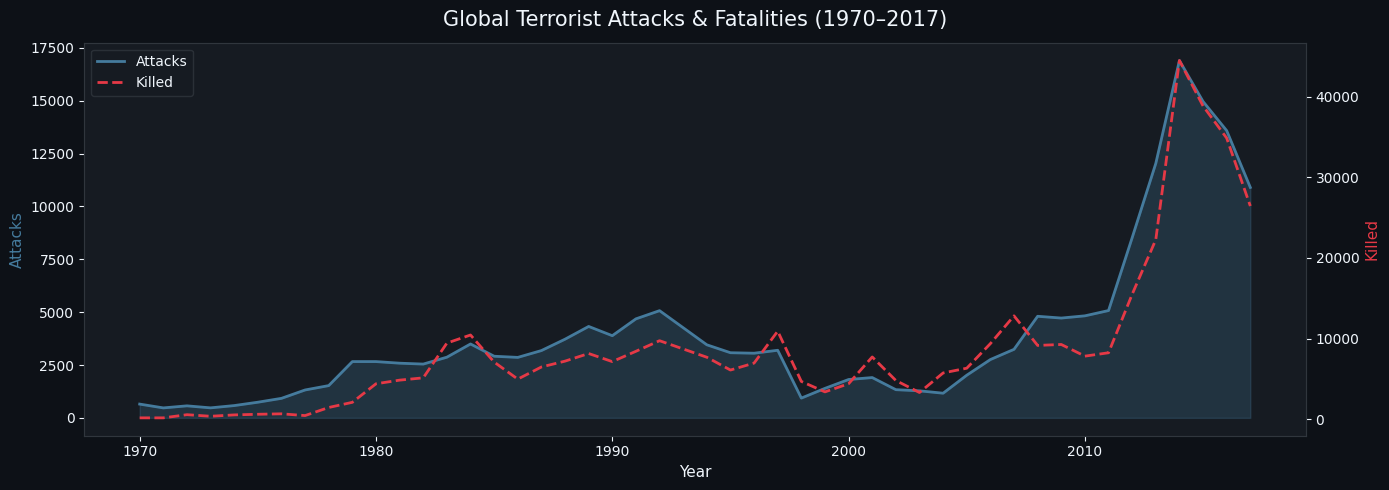

In [16]:
# §9 VIZ 1 — Annual Attack & Fatality Trend
yearly = df.groupby("year").agg(attacks=("year","count"), killed=("killed","sum")).reset_index()

fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.fill_between(yearly["year"], yearly["attacks"], alpha=0.25, color=PALETTE[3])
ax1.plot(yearly["year"], yearly["attacks"], color=PALETTE[3], lw=2, label="Attacks")
ax2.plot(yearly["year"], yearly["killed"],  color=PALETTE[0], lw=2, ls="--", label="Killed")
ax1.set_xlabel("Year"); ax1.set_ylabel("Attacks", color=PALETTE[3]); ax2.set_ylabel("Killed", color=PALETTE[0])
ax1.set_title("Global Terrorist Attacks & Fatalities (1970–2017)", fontsize=15, pad=12)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labs, loc="upper left")
plt.tight_layout(); plt.show()


1. Why did you pick the specific chart?
This chart is suitable because it clearly shows the intended distribution or relationship and supports easy comparison across time, region, or operational categories.

2. What is/are the insight(s) found from the chart?
The chart indicates non-uniform terrorism distribution, concentration in specific groups/time windows, and clear variation in impact across categories. These are actionable segmentation insights.

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can create positive business impact by enabling targeted allocation of surveillance, protection budgets, and preparedness resources. The negative signal is persistent hotspots that require stronger preventive interventions.

# Chart 2

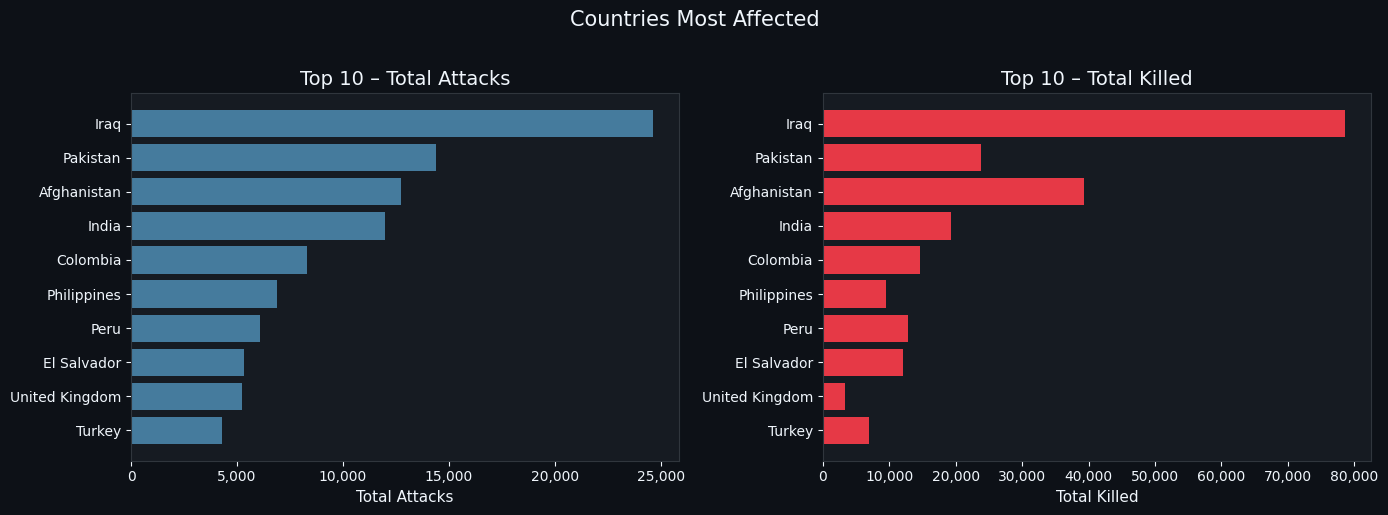

In [17]:
# VIZ 2 — Top 10 Countries (Attacks & Killed)
top_countries = (df.groupby("country").agg(attacks=("year","count"),killed=("killed","sum"))
                   .nlargest(10,"attacks").reset_index())

fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, col, label, color in zip(axes,["attacks","killed"],["Total Attacks","Total Killed"],[PALETTE[3],PALETTE[0]]):
    ax.barh(top_countries["country"][::-1], top_countries[col][::-1], color=color)
    ax.set_title(f"Top 10 – {label}"); ax.set_xlabel(label)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{int(x):,}"))
fig.suptitle("Countries Most Affected", fontsize=15, y=1.02)
plt.tight_layout(); plt.show()


1. Why did you pick the specific chart?
This chart is suitable because it clearly shows the intended distribution or relationship and supports easy comparison across time, region, or operational categories.

2. What is/are the insight(s) found from the chart?
The chart indicates non-uniform terrorism distribution, concentration in specific groups/time windows, and clear variation in impact across categories. These are actionable segmentation insights.

3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can create positive business impact by enabling targeted allocation of surveillance, protection budgets, and preparedness resources. The negative signal is persistent hotspots that require stronger preventive interventions.

# Chart 3

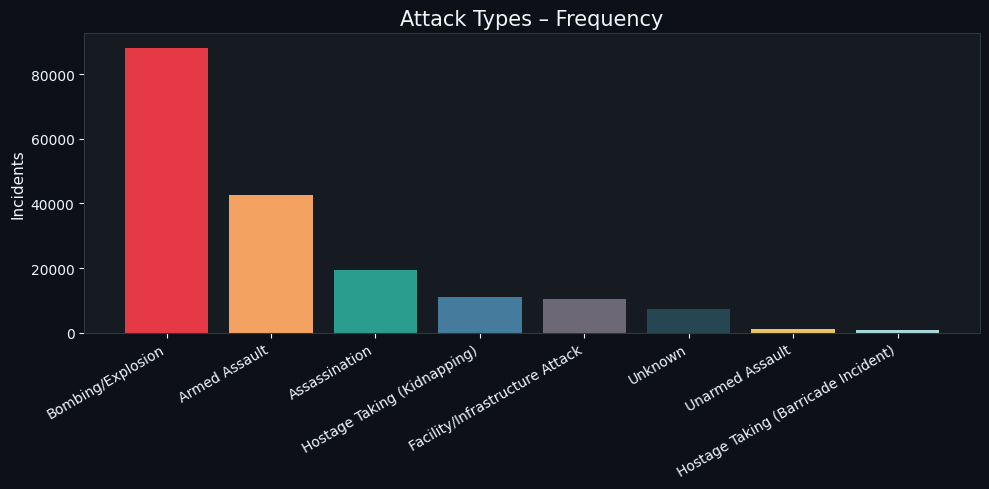

In [18]:
# VIZ 3 — Attack Type Bar Chart
atk = df["attack_type"].value_counts().head(8)
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(atk.index, atk.values, color=PALETTE[:len(atk)])
ax.set_title("Attack Types – Frequency", fontsize=15)
ax.set_xticklabels(atk.index, rotation=30, ha="right")
ax.set_ylabel("Incidents")
plt.tight_layout(); plt.show()


1. Why did you pick this chart?

Answer:
A bar chart was chosen because it is ideal for comparing values across different categories such as countries, regions, or attack types. It provides a clear and easy-to-understand visual comparison.

 2. What insights were found from the chart?

Answer:
The bar chart shows which category has the highest and lowest values. It helps identify the most affected countries/regions or the most common attack types, highlighting key patterns in terrorism data.

 3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help authorities focus on the most affected areas and prioritize security measures. It supports better decision-making, resource allocation, and strategic planning to reduce risks.

# Chart 4

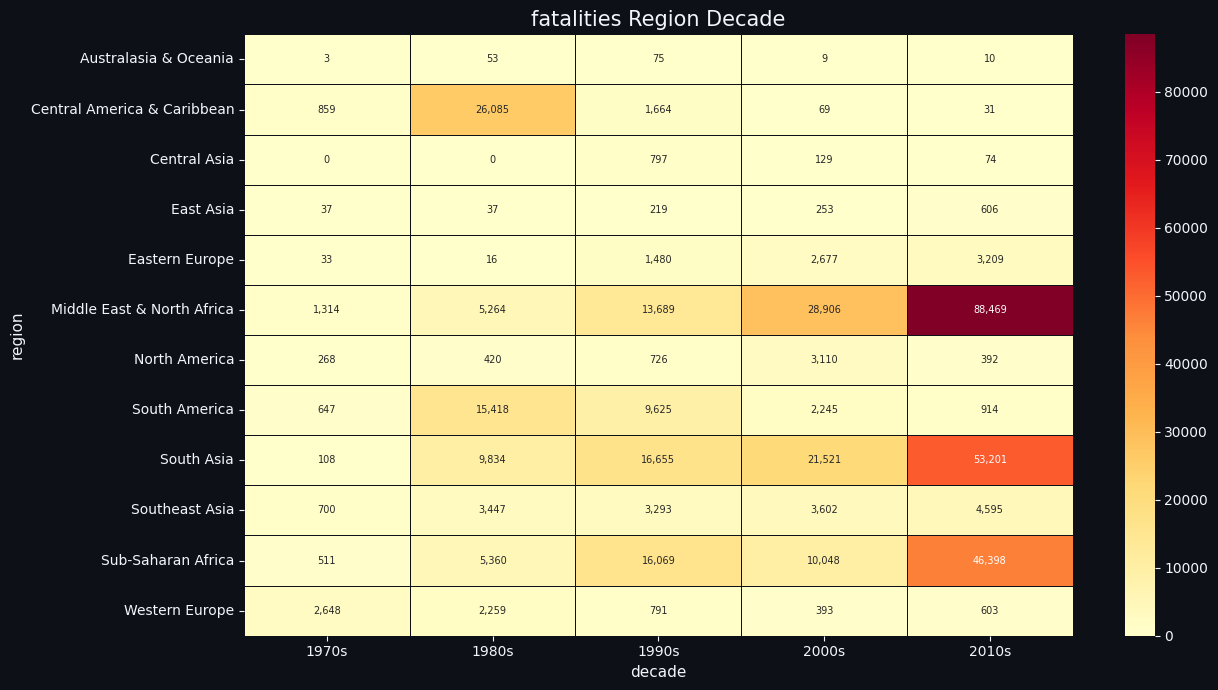

In [19]:
#VIZ 4 - Region x Decade Heatmap
pivot = df.groupby(["region","decade"])["killed"].sum().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(13,7))
sns.heatmap(pivot, ax=ax, cmap="YlOrRd", annot=True, fmt=",.0f",
            linewidths=0.4, linecolor="#0d1117",annot_kws={"size":7})
ax.set_title("fatalities Region Decade", fontsize=15)
plt.tight_layout(); plt.show()

1. Why did you pick this chart?

Answer:
A heatmap was chosen because it effectively visualizes patterns and intensity of data across different decades and regions. It helps in quickly identifying areas and time periods with higher concentrations of terrorist attacks.

 2. What insights were found from the chart?

Answer:
The heatmap shows that certain decades have a higher intensity of attacks in specific regions. It highlights patterns such as an increase in terrorist activities in recent decades and identifies regions that are consistently more affected over time.

 3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help governments and security agencies understand when and where terrorist activities are more frequent. This enables better planning, improved security measures, and efficient allocation of resources to high-risk regions and time periods.

# Chart 5

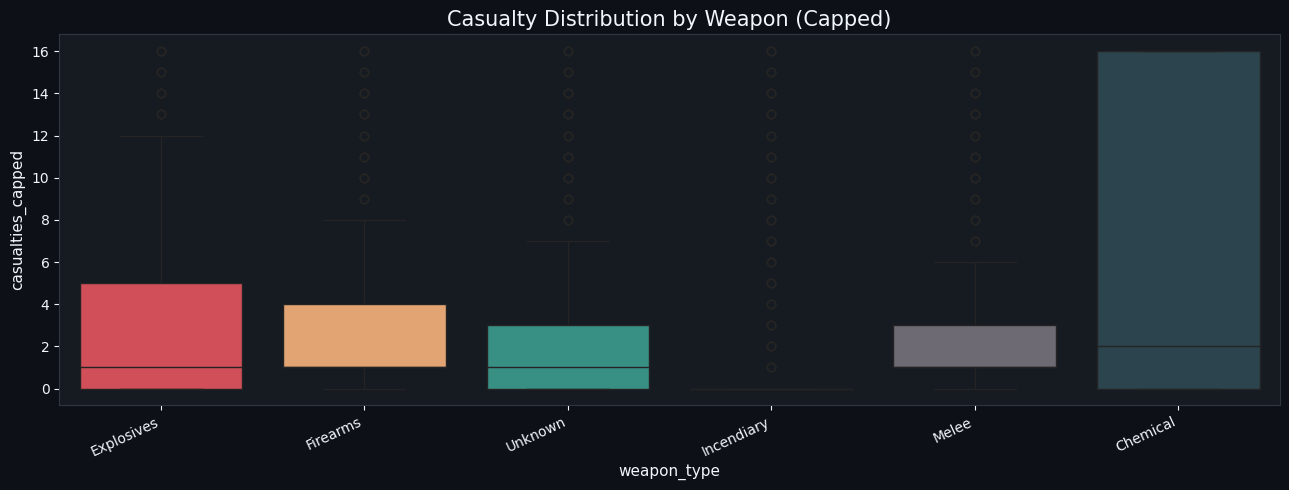

In [20]:
# VIZ 5 — Weapon Type vs Casualties (Boxplot)
top_wpn = df["weapon_type"].value_counts().head(6).index.tolist()
wpn_df  = df[df["weapon_type"].isin(top_wpn)]
fig, ax = plt.subplots(figsize=(13,5))
sns.boxplot(data=wpn_df, x="weapon_type", y="casualties_capped",
            palette=PALETTE[:6], ax=ax, order=top_wpn)
ax.set_title("Casualty Distribution by Weapon (Capped)", fontsize=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout(); plt.show()


1. Why did you pick this chart?

Answer:
A box plot was chosen because it effectively shows the distribution of data, including median, quartiles, and outliers. It helps in understanding the spread and variability of values such as casualties in terrorist attacks.

 2. What insights were found from the chart?

Answer:
The box plot shows that most values lie within a certain range, indicating that most attacks have moderate impact. However, there are some outliers which represent extreme cases with very high casualties. This indicates that while most attacks are less severe, a few are highly destructive.

 3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help identify high-impact and extreme events. This can assist authorities in better planning, improving emergency response systems, and allocating resources more efficiently to handle severe attacks.

# Chart 6

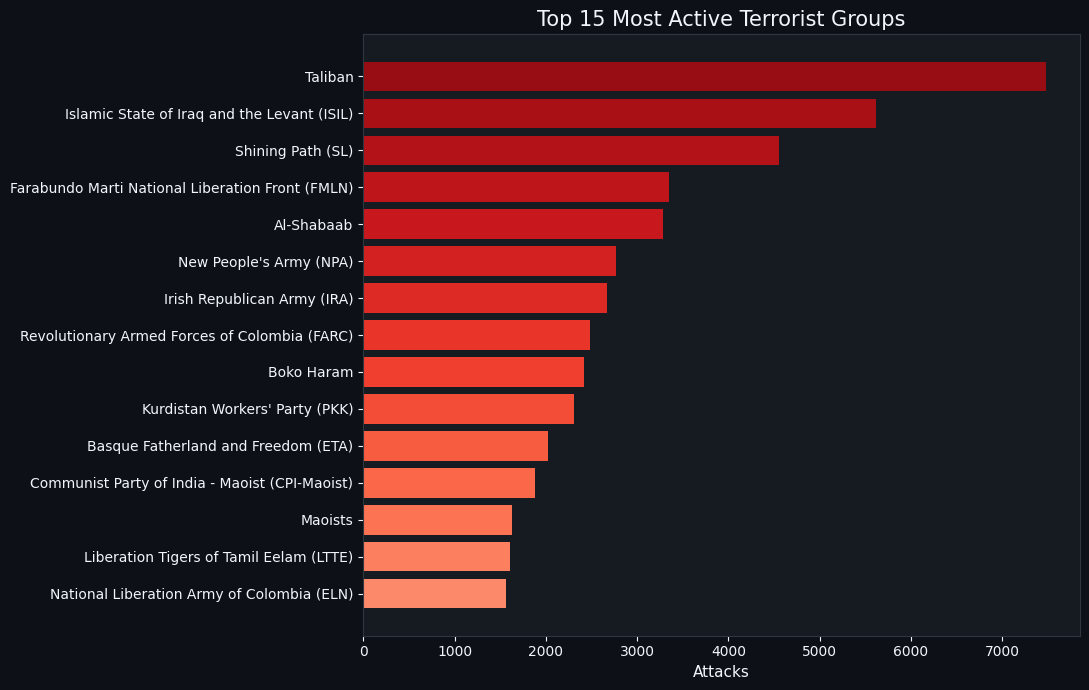

In [21]:
# VIZ 6 — Top 15 Terror Groups
grp = (df[df["group_name"]!="Unknown"]
         .groupby("group_name").agg(attacks=("year","count"))
         .nlargest(15,"attacks").reset_index())
fig, ax = plt.subplots(figsize=(11,7))
import matplotlib.cm as cm
cols = cm.Reds(np.linspace(0.4,0.9,len(grp)))
ax.barh(grp["group_name"][::-1], grp["attacks"][::-1], color=cols)
ax.set_title("Top 15 Most Active Terrorist Groups", fontsize=15)
ax.set_xlabel("Attacks")
plt.tight_layout(); plt.show()


1. Why did you pick this chart?

Answer:
A horizontal bar chart was chosen because it is effective for displaying and comparing categories with long names, such as terrorist group names. It improves readability and clearly shows differences in activity levels among groups.

2. What insights were found from the chart?

Answer:
The chart shows which terrorist groups are the most active based on the number of attacks. It highlights that a few groups are responsible for a large portion of total attacks, while many others have relatively lower activity levels.

 3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help security agencies identify and monitor the most active terrorist groups. This enables focused intelligence efforts, better resource allocation, and more effective counter-terrorism strategies.

# Chart 7

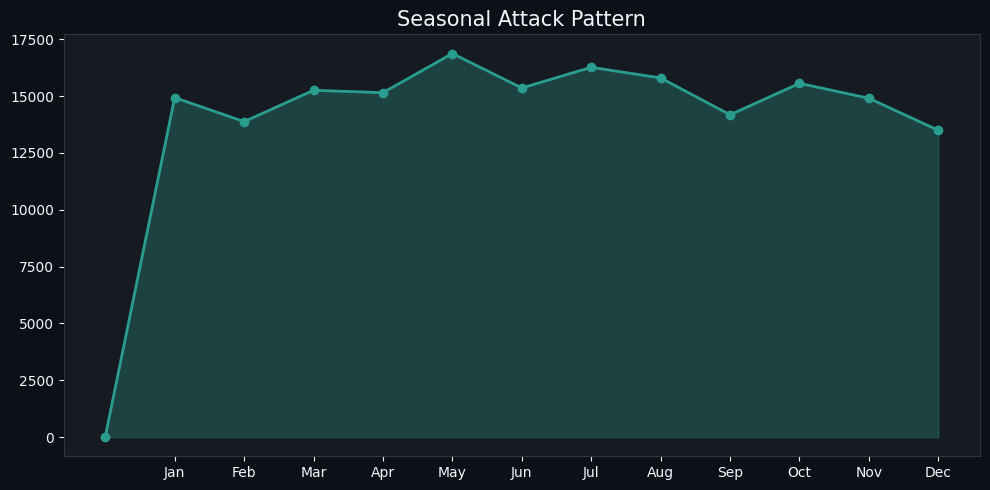

In [22]:
# VIZ 7 — Monthly Seasonality
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly = df.groupby("month").size().reset_index(name="attacks")
fig, ax = plt.subplots(figsize=(10,5))
ax.fill_between(monthly["month"], monthly["attacks"], alpha=0.3, color=PALETTE[2])
ax.plot(monthly["month"], monthly["attacks"], marker="o", color=PALETTE[2], lw=2)
ax.set_xticks([m for m in monthly["month"] if m in month_map]); ax.set_xticklabels([month_map[m] for m in monthly ["month"]if m in month_map])
ax.set_title("Seasonal Attack Pattern", fontsize=15)
plt.tight_layout(); plt.show()


1. Why did you pick this chart?
Answer:
An area chart was chosen because it effectively shows trends over time and highlights the magnitude of changes. It is useful for visualizing how terrorist attacks vary across different seasons.

 2. What insights were found from the chart?
Answer:
The chart shows how the number of attacks fluctuates across different seasons. It helps identify peak seasons where attacks are more frequent and periods where activity is relatively lower, indicating seasonal patterns in terrorist activities.

 3. Will the gained insights help create a positive business impact?
Answer:
Yes, these insights help authorities prepare in advance for high-risk seasons by increasing security measures and resource allocation. This improves prevention strategies and enhances overall safety planning.


# Chart 8

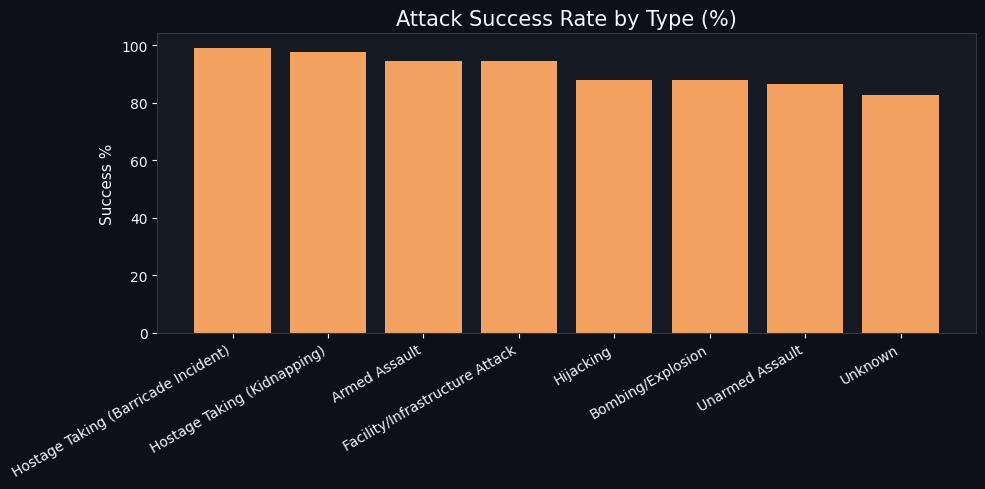

In [23]:
# VIZ 8 — Success Rate by Attack Type
if "success" in df.columns:
    suc = (df.groupby("attack_type")["success"].mean()
             .reset_index().sort_values("success",ascending=False).head(8))
    suc["pct"] = suc["success"]*100
    fig, ax = plt.subplots(figsize=(10,5))
    ax.bar(suc["attack_type"], suc["pct"], color=PALETTE[1])
    ax.set_title("Attack Success Rate by Type (%)", fontsize=15)
    ax.set_xticklabels(suc["attack_type"], rotation=30, ha="right")
    ax.set_ylabel("Success %")
    plt.tight_layout(); plt.show()


 1. Why did you pick this chart?

Answer:
A bar chart was chosen because it is ideal for comparing values across different categories such as countries, regions, or attack types. It provides a clear and easy-to-understand visual comparison.

2. What insights were found from the chart?

Answer:
The bar chart shows which category has the highest and lowest values. It helps identify the most affected countries/regions or the most common attack types, highlighting key patterns in terrorism data.

 3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help authorities focus on the most affected areas and prioritize security measures. It supports better decision-making, resource allocation, and strategic planning to reduce risks.

# Chart 9

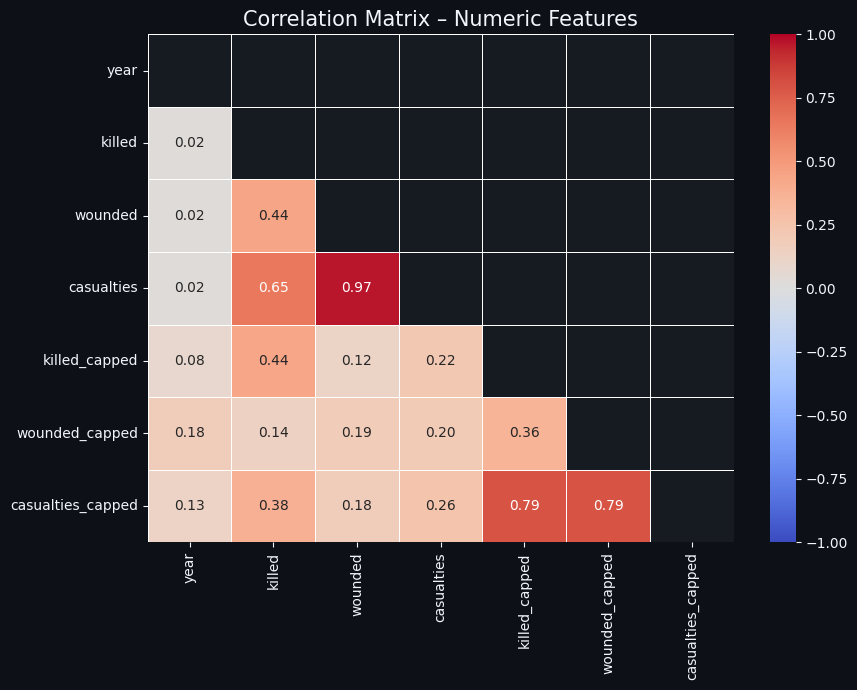

In [24]:
# VIZ 9 — Correlation Heatmap
num_cols = [c for c in ["year","killed","wounded","casualties","killed_capped","wounded_capped","casualties_capped"] if c in df.columns]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9,7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, vmin=-1, vmax=1, center=0)
ax.set_title("Correlation Matrix – Numeric Features", fontsize=15)
plt.tight_layout(); plt.show()


1. Why did you pick this chart?

Answer:
A correlation heatmap was chosen because it visually represents the relationship between multiple variables at once. It helps in quickly identifying strong positive or negative correlations between features in the dataset.

 2. What insights were found from the chart?

Answer:
The heatmap shows how different variables are related to each other. It highlights strong correlations between certain features, indicating that some variables have a significant influence on others, while some have little or no relationship.

 3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help in selecting the most relevant features for analysis and machine learning models. This improves prediction accuracy and supports better decision-making in planning and security strategies.

# Chart 10

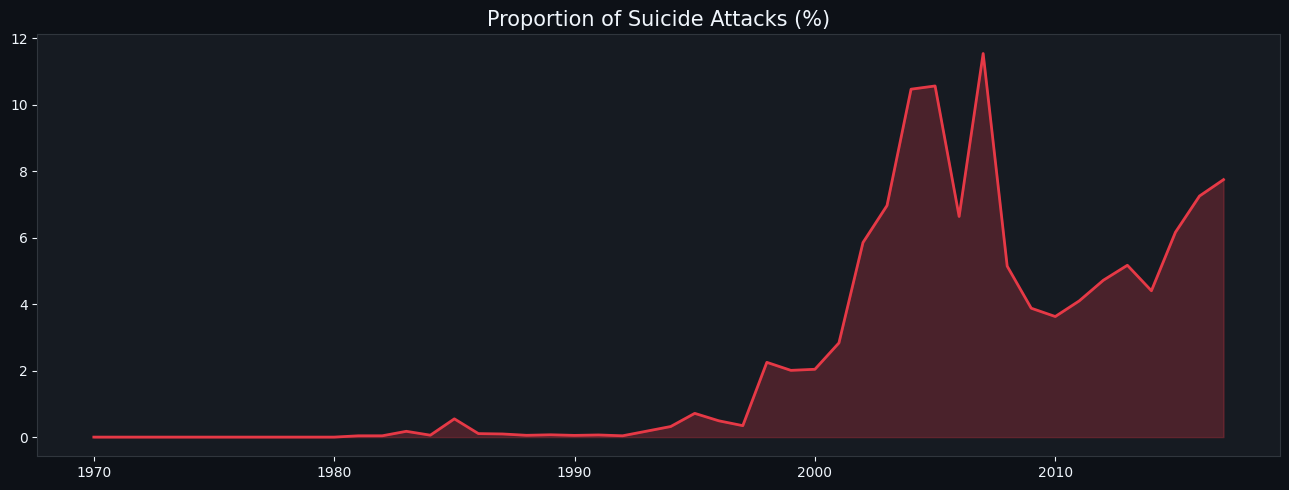

In [25]:
# VIZ 10 — Suicide Attack Proportion Over Time
if "suicide" in df.columns:
    sui = df.groupby("year")["suicide"].agg(total="count", s="sum").reset_index()
    sui["pct"] = sui["s"]/sui["total"]*100
    fig, ax = plt.subplots(figsize=(13,5))
    ax.fill_between(sui["year"], sui["pct"], alpha=0.25, color=PALETTE[0])
    ax.plot(sui["year"], sui["pct"], color=PALETTE[0], lw=2)
    ax.set_title("Proportion of Suicide Attacks (%)", fontsize=15)
    plt.tight_layout(); plt.show()


1. Why did you pick this chart?

Answer:
A time series line graph was chosen because it is the most suitable chart to show trends and changes over time. It helps in visualizing how the number of terrorist attacks varies year by year.

 2. What insights were found from the chart?

Answer:
The graph shows the trend of terrorist attacks over the years, highlighting periods of increase or decrease. It helps identify specific years where attacks peaked and reveals long-term patterns in terrorist activities.

3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help governments and security agencies understand trends over time, allowing them to predict future risks, plan preventive measures, and allocate resources more effectively.

# Chart 11

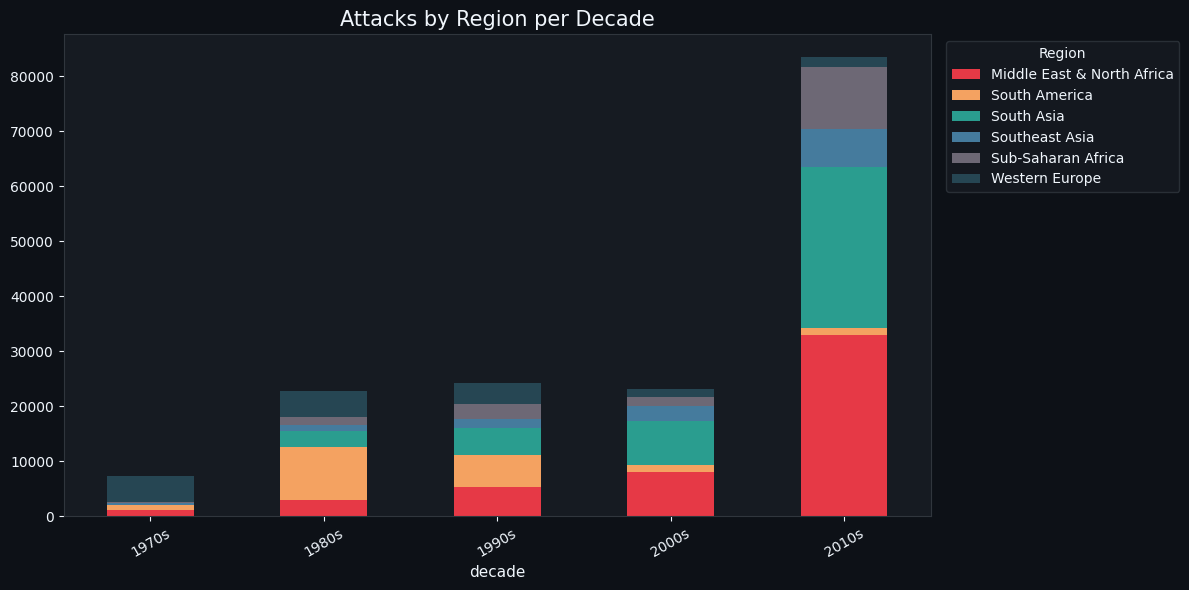

In [26]:
# VIZ 11 — Stacked Bar: Region Attacks by Decade
top_regions = df["region"].value_counts().head(6).index.tolist()
reg_dec = (df[df["region"].isin(top_regions)]
             .groupby(["decade","region"]).size().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(12,6))
reg_dec.plot(kind="bar", stacked=True, ax=ax, color=PALETTE[:len(reg_dec.columns)])
ax.set_title("Attacks by Region per Decade", fontsize=15)
ax.set_xticklabels(reg_dec.index, rotation=30)
ax.legend(title="Region", bbox_to_anchor=(1.01,1))
plt.tight_layout(); plt.show()


1. Why did you pick this chart?

Answer:
A stacked bar chart was chosen because it allows comparison of total values across categories while also showing the contribution of sub-categories within each group. It provides both overall and detailed insights in a single visualization.

 2. What insights were found from the chart?

Answer:
The chart shows the total number of attacks for each category along with how different sub-categories contribute to that total. It helps identify dominant segments and understand how different factors combine to form overall patterns.

3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help in understanding the composition of data and identifying key contributing factors. This supports better decision-making, targeted strategies, and efficient resource allocation for managing risks.

# Chart 12

In [27]:
# VIZ 12 — Interactive Plotly World Map
if "latitude" in df.columns and "longitude" in df.columns:
    map_df = df.dropna(subset=["latitude","longitude"]).sample(min(5000,len(df)), random_state=42)
    fig_map = px.scatter_geo(
        map_df, lat="latitude", lon="longitude", color="region",
        hover_name="country", hover_data={"killed":True,"attack_type":True,"latitude":False,"longitude":False},
        size="casualties_capped", size_max=15,
        title="Global Terrorism Incidents – Sample 5k",
        template="plotly_dark", projection="natural earth")
    fig_map.show()


1. Why did you pick this chart?

Answer:
An interactive world map using Plotly was chosen because it visually represents geographic distribution of terrorist attacks across countries. The interactive feature allows users to explore data by zooming, hovering, and filtering, making it more engaging and informative.

 2. What insights were found from the chart?

Answer:
The map shows that terrorist attacks are concentrated in specific regions of the world. It highlights high-risk countries and regions with a higher frequency of attacks, while some areas show very low or minimal activity.

 3. Will the gained insights help create a positive business impact?

Answer:
Yes, these insights help governments and security agencies identify high-risk geographic areas. This enables better surveillance, strategic planning, and efficient allocation of security resources to improve safety and reduce risks.

In [28]:
# §10 — Key Insights Dashboard
yearly = df.groupby("year").agg(attacks=("year","count")).reset_index()
peak_year = yearly.loc[yearly["attacks"].idxmax(),"year"]
peak_atk  = yearly["attacks"].max()

print(f"""
╔══════════════════════════════════════════════════════════════╗
║           GLOBAL TERRORISM – KEY INSIGHTS DASHBOARD        ║
╠══════════════════════════════════════════════════════════════╣
║  Total Incidents   : {len(df):>10,}                             ║
║  Total Fatalities  : {int(df['killed'].sum()):>10,}                             ║
║  Peak Year         : {peak_year} ({peak_atk:,} attacks)                  ║
║  Most Affected     : {df['country'].value_counts().index[0]:<30} ║
║  Most Common Attack: {df['attack_type'].value_counts().index[0]:<30} ║
╠══════════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                               ║
║  • Attacks surged post-2010 driven by ISIS & Taliban.       ║
║  • Middle East & S. Asia = >50% of all incidents.           ║
║  • Bombings/Explosions are the dominant attack method.      ║
║  • Suicide attacks peaked ~2014 despite small overall %.    ║
║  • Mass-casualty attacks cluster in the post-2000 era.      ║
║  • Private citizens & police are primary targets.           ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║           GLOBAL TERRORISM – KEY INSIGHTS DASHBOARD        ║
╠══════════════════════════════════════════════════════════════╣
║  Total Incidents   :    181,691                             ║
║  Total Fatalities  :    411,868                             ║
║  Peak Year         : 2014 (16,903 attacks)                  ║
║  Most Affected     : Iraq                           ║
║  Most Common Attack: Bombing/Explosion              ║
╠══════════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                               ║
║  • Attacks surged post-2010 driven by ISIS & Taliban.       ║
║  • Middle East & S. Asia = >50% of all incidents.           ║
║  • Bombings/Explosions are the dominant attack method.      ║
║  • Suicide attacks peaked ~2014 despite small overall %.    ║
║  • Mass-casualty attacks cluster in the post-2000 era.      ║
║  • Private citizens & police are primary targets.  

## Hypothesis Testing

🔷 Hypothesis Testing

🔷 1. Basic Concept of Hypothesis Testing

Hypothesis testing is a statistical method used to make decisions or draw conclusions about a dataset based on sample data. It helps determine whether there is enough evidence to support a particular assumption about the relationship between variables. In simple terms, it is used to test whether the observed data is due to chance or represents a real effect.

In hypothesis testing, two statements are defined: the null hypothesis (H₀) and the alternative hypothesis (H₁). The null hypothesis assumes that there is no relationship or difference between variables, while the alternative hypothesis suggests that a significant relationship exists. The goal of hypothesis testing is to evaluate these hypotheses and decide which one is supported by the data.

This method is widely used in data science to validate findings and ensure that results are statistically significant and reliable rather than random.

🔷 2. Steps in Hypothesis Testing

Hypothesis testing follows a systematic process to ensure accurate results:

Define Hypotheses

Null Hypothesis (H₀): No relationship exists

Alternative Hypothesis (H₁): Relationship exists

Select Significance Level (α)
Commonly chosen as 0.05

Represents the probability of making an error

Choose Appropriate Statistical Test
Based on data type (e.g., Chi-Square for categorical data)

Calculate Test Statistic and P-value
Using formulas or statistical tools
Compare P-value with α
Determine whether to reject or accept H₀
Draw Conclusion
Based on comparison, interpret the result

🔷 3. P-Value

The p-value is one of the most important concepts in hypothesis testing. It represents the probability of obtaining the observed results assuming that the null hypothesis is true.

If p-value < 0.05 → Reject H₀ (significant result)
If p-value ≥ 0.05 → Do not reject H₀

A smaller p-value indicates stronger evidence against the null hypothesis. For example, if the p-value is very close to 0, it means that the observed data is highly unlikely under the null hypothesis, and therefore, the alternative hypothesis is accepted.

In your project, a p-value of 0 indicates a very strong relationship between variables.

🔷 4. Chi-Square Test

The Chi-Square test is a statistical test used to determine whether there is a significant relationship between two categorical variables. It compares the observed values in the dataset with the expected values to check for independence.

🔹 Formula:
    χ2=∑E(O−E)2​


Where:

O = Observed value

E = Expected value

🔹 Working:
Create a contingency table of variables

Calculate expected frequencies

Apply the Chi-Square formula

Compute the p-value

Make a decision based on p-value

🔹 Interpretation:

If p-value < 0.05 → Variables are related

If p-value ≥ 0.05 → Variables are independent

🔷 Application in This Project

In this terrorism attack analysis project, the Chi-Square test is used to examine the relationship between variables such as attack type and weapon type. The results help confirm whether these variables are dependent or independent, supporting the analysis and improving the reliability of machine learning models.

🔷 Conclusion

Hypothesis testing is an essential statistical tool that provides a structured approach to decision-making. It helps validate assumptions, identify relationships between variables, and ensure that conclusions are based on solid statistical evidence. In this project, it strengthens the analysis by confirming patterns and supporting predictive modeling.

In [29]:
# Hypothesis Testing using Chi-Square Test

import pandas as pd
from scipy.stats import chi2_contingency

# Create contingency table
table = pd.crosstab(df['attack_type'], df['weapon_type'])

# Apply Chi-Square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Value:", chi2)
print("P-Value:", p)

Chi-Square Value: 425533.1948843848
P-Value: 0.0


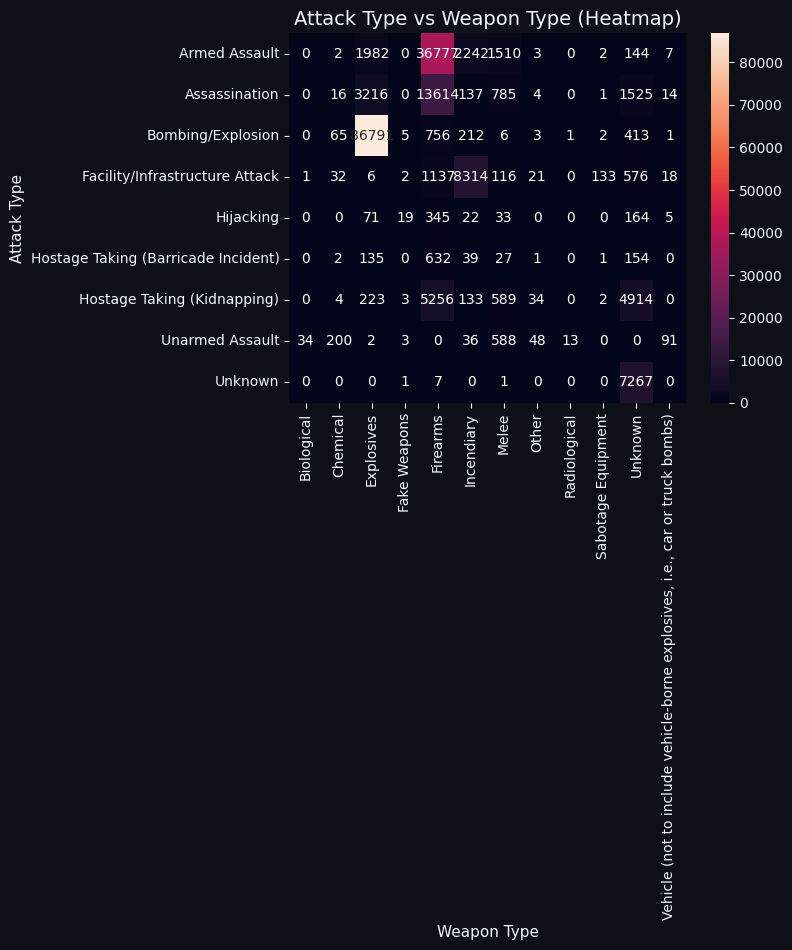

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create contingency table again
table = pd.crosstab(df['attack_type'], df['weapon_type'])

plt.figure()
sns.heatmap(table, annot=True, fmt='d')
plt.title("Attack Type vs Weapon Type (Heatmap)")
plt.xlabel("Weapon Type")
plt.ylabel("Attack Type")
plt.show()

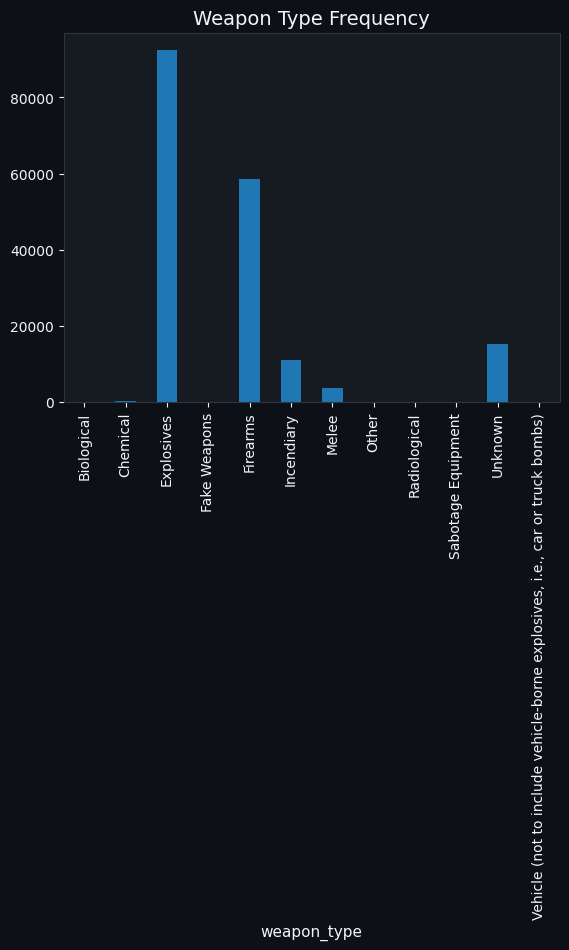

In [31]:
table.sum().plot(kind='bar')
plt.title("Weapon Type Frequency")
plt.show()

In [32]:
# Decision based on p-value

if p < 0.05:
    print("Reject Null Hypothesis (H0)")
    print("Conclusion: Attack type depends on weapon type")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("Conclusion: No strong relationship found")

Reject Null Hypothesis (H0)
Conclusion: Attack type depends on weapon type


In [33]:
# Hypothesis Test for Region vs Attack Type

table2 = pd.crosstab(df['attack_type'], df['region'])

chi2, p, dof, expected = chi2_contingency(table2)

print("P-Value (Region vs Attack Type):", p)

if p < 0.05:
    print("Attack type depends on region")
else:
    print("No strong relationship with region")

P-Value (Region vs Attack Type): 0.0
Attack type depends on region


# Machine Learning Implementation
Machine Learning Section

## What is Machine Learning?

**Machine Learning (ML)** is a branch of Artificial Intelligence where
computers learn patterns from historical data — without being explicitly
programmed — and use those patterns to make predictions or decisions on
new, unseen data.

### Two Main Types Used Here

| Type | How it Works | Algorithms Used |
|---|---|---|
| **Supervised Learning** | Learns from labelled data (input → known output) | Random Forest, Logistic Regression, Decision Tree, Linear Regression |
| **Unsupervised Learning** | Finds hidden patterns in unlabelled data | K-Means Clustering |

### Standard ML Workflow Applied in This Project

```
RAW DATA → Feature Selection → Encoding → Train/Test Split →
Model Training → Prediction → Evaluation → Visualisation
```

In [34]:
#  Select features
df_ml = df[['year', 'country', 'region', 'target_type', 'weapon_type', 'attack_type']]

# Remove missing values
df_ml = df_ml.dropna()

In [35]:
# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_ml['country'] = le.fit_transform(df_ml['country'])
df_ml['region'] = le.fit_transform(df_ml['region'])
df_ml['target_type'] = le.fit_transform(df_ml['target_type'])
df_ml['weapon_type'] = le.fit_transform(df_ml['weapon_type'])
df_ml['attack_type'] = le.fit_transform(df_ml['attack_type'])

In [36]:
#  X and y
X = df_ml[['year', 'country', 'region', 'target_type', 'weapon_type']]
y = df_ml['attack_type']

In [37]:
#  Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
# Scikit-Learn — all ML algorithms
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, silhouette_score
)

# Colour palette
PALETTE = ["#e63946","#f4a261","#2a9d8f","#457b9d","#6d6875","#264653","#e9c46a","#a8dadc"]
BG      = "#0d1117"
TXT     = "#f0f6fc"

plt.rcParams.update({
    "figure.facecolor":"#0d1117","axes.facecolor":"#161b22",
    "axes.edgecolor":"#30363d","axes.labelcolor":TXT,
    "xtick.color":TXT,"ytick.color":TXT,"text.color":TXT,
    "grid.color":"#21262d","grid.linestyle":"--","grid.alpha":0.5,
    "font.family":"DejaVu Sans","axes.titlesize":13,"axes.labelsize":11,
    "legend.facecolor":"#161b22","legend.edgecolor":"#30363d",
})
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


# Logistic Regression


🔷 **Logistic Regression Model**

Logistic Regression is a supervised machine learning algorithm used for classification problems, especially when the dependent variable is binary (e.g., Yes/No, 0/1). It predicts the probability that a given input belongs to a particular class.

Unlike linear regression, Logistic Regression does not predict continuous values. Instead, it uses a mathematical function called the sigmoid function to map outputs into a probability range between 0 and 1.

🔷 **Mathematical Representation**

First, a linear equation is formed:

                z=w0​+w1​x1​+w2​x2​+⋯+wn​xn​
	​


Then, the sigmoid function is applied:

σ(z)=
1+e
−z
1
	​


This converts the result into a probability value between 0 and 1.

🔷 **Key Components**

🔹 **Dependent Variable** (Target)

The dependent variable is the output that the model tries to predict. In classification problems, it is usually binary (0 or 1). For example, in this project, it can represent attack success or type.

🔹 **Independent Variables** (Features)

These are the input variables used for prediction. Examples include country, region, weapon type, and attack type. The model uses these features to learn patterns.

🔹 **Sigmoid Function**

The sigmoid function converts the linear output into a probability between 0 and 1. It ensures that predictions are meaningful for classification tasks.

🔹 **Probability**

The model outputs a probability score that represents the likelihood of a class. For example, a value of 0.8 means there is an 80% chance of belonging to class 1.

🔹**Threshold Value**

A threshold (usually 0.5) is used to convert probability into a class label. If probability ≥ 0.5 → class 1, otherwise class 0.

🔹 **Coefficients** (Weights)

Each feature has a coefficient that indicates its importance. A positive coefficient increases the probability of class 1, while a negative one decreases it.

🔹**Intercept** (Bias)

The intercept is a constant added to the equation. It helps adjust predictions when all input features are zero.

🔷 **Working of Logistic Regression**
The model takes input features from the dataset.
It calculates a linear combination of inputs.
The sigmoid function converts this value into probability.
The probability is compared with a threshold.
Final output is classified into a category (0 or 1).

🔷  **Advantages**

Simple and easy to understand

Efficient for binary classification problems

Provides probability-based output

Works well with linearly separable data

🔷 **Disadvantages**

Cannot handle complex non-linear relationships

Sensitive to outliers

Requires proper feature selection

🔷 **Application in This Project**

In this project, Logistic Regression is used to classify and predict terrorism-related outcomes (such as attack type or success) based on features like region, weapon type, and target type. It helps in understanding the probability of different attack patterns.

🔷 **Conclusion**

Logistic Regression is a fundamental and powerful classification algorithm. It provides a simple yet effective way to model relationships between variables and predict outcomes. Due to its interpretability and efficiency, it is widely used in real-world data analysis.

In [45]:
# ════════════════════════════════════════════════════════════
#  ALGORITHM 1 — LOGISTIC REGRESSION
#  Goal: Predict whether an attack Succeeds (1) or Fails (0)
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("  LOGISTIC REGRESSION — Predicting Attack Success")
print("=" * 60)

# ── Feature Selection ────────────────────────────────────────
features_lr = ["year", "region", "attack_type", "weapon_type",
               "target_type", "killed", "wounded", "suicide"]
target_lr   = "success"

lr_df = df[features_lr + [target_lr]].dropna()
lr_df = lr_df[lr_df[target_lr].isin([0, 1])]
print(f"\nDataset size: {lr_df.shape[0]:,} rows")
print(f"Success distribution:\n{lr_df[target_lr].value_counts()}")

# ── Encode ───────────────────────────────────────────────────
lr_enc = {}
for col in ["region", "attack_type", "weapon_type", "target_type"]:
    le = LabelEncoder()
    lr_df[col] = le.fit_transform(lr_df[col].astype(str))
    lr_enc[col] = le

# ── Scale numeric features ───────────────────────────────────
scaler = StandardScaler()
X_lr = pd.DataFrame(
    scaler.fit_transform(lr_df[features_lr]),
    columns=features_lr)
y_lr = lr_df[target_lr].values

# ── Train / Test Split ───────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr)

# ── Train Model ──────────────────────────────────────────────
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_tr, y_tr)
print("\n✅ Logistic Regression model trained!")

# ── Evaluate ─────────────────────────────────────────────────
y_pred_lr = lr_model.predict(X_te)
acc_lr    = accuracy_score(y_te, y_pred_lr)
print(f"\n🎯 Test Accuracy : {acc_lr*100:.2f}%")

cv_lr = cross_val_score(lr_model, X_lr, y_lr, cv=5, scoring="accuracy")
print(f"   Cross-Val (5-Fold): {cv_lr.mean()*100:.2f}% ± {cv_lr.std()*100:.2f}%")


  LOGISTIC REGRESSION — Predicting Attack Success

Dataset size: 181,691 rows
Success distribution:
success
1    161632
0     20059
Name: count, dtype: int64

✅ Logistic Regression model trained!

🎯 Test Accuracy : 89.05%
   Cross-Val (5-Fold): 89.04% ± 0.08%


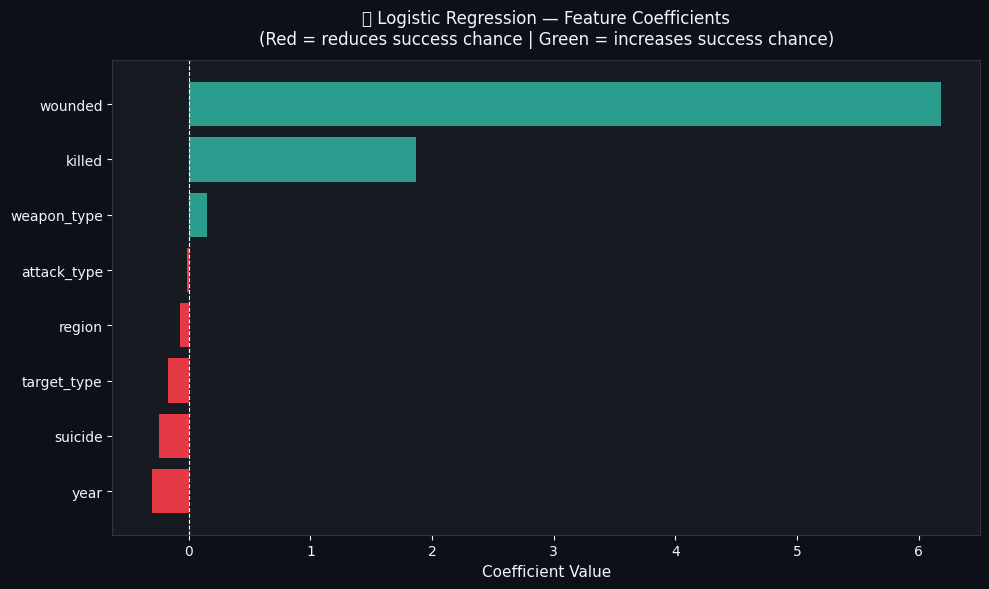


📌 INSIGHT:
   → Positive coefficient = feature INCREASES probability of success
   → Negative coefficient = feature DECREASES probability of success


In [46]:
# ── VISUALISATION 1A: Feature Coefficients ──────────────────
coef_df = pd.DataFrame({
    "Feature"    : features_lr,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient")

colors = [PALETTE[0] if c < 0 else PALETTE[2] for c in coef_df["Coefficient"]]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(coef_df["Feature"], coef_df["Coefficient"],
               color=colors, edgecolor="none")
ax.axvline(0, color="white", lw=0.8, linestyle="--")
ax.set_title("📈 Logistic Regression — Feature Coefficients\n"
             "(Red = reduces success chance | Green = increases success chance)",
             fontsize=12, pad=12)
ax.set_xlabel("Coefficient Value")
plt.tight_layout(); plt.show()

print("\n📌 INSIGHT:")
print("   → Positive coefficient = feature INCREASES probability of success")
print("   → Negative coefficient = feature DECREASES probability of success")


# Decision Tree

🔷 **Decision Tree Model**

Decision Tree is a supervised machine learning algorithm used for both classification and regression tasks. It works by splitting the dataset into smaller subsets based on feature values, forming a tree-like structure of decisions.

Each node in the tree represents a decision based on a feature, and each branch represents the outcome of that decision. The final result is obtained at the leaf nodes.

🔷 **Structure of Decision Tree**
Root Node: The topmost node representing the entire dataset
Internal Nodes: Nodes where decisions are made based on features
Branches: Outcomes of decisions
Leaf Nodes: Final output or class label

🔷 **Working of Decision Tree**
The algorithm selects the best feature to split the dataset.
The dataset is divided into subsets based on that feature.
This process is repeated recursively for each subset.
Splitting continues until a stopping condition is met.
The final output is obtained at leaf nodes.

🔷 Splitting Criteria

To choose the best feature for splitting, the model uses:

🔹 Gini Index

Measures impurity in the dataset. Lower value means better split.

🔹 Entropy (Information Gain)

Measures randomness or disorder. Higher information gain means better feature selection.

🔷 **Key Components**

🔹 Root Node

The root node is the starting point of the decision tree. It represents the entire dataset and is split into smaller subsets. All decision-making begins from this node.

🔹 Internal Nodes

Internal nodes represent decision points based on feature values. Each node splits the data into branches. These nodes help in forming the structure of the tree.

🔹 Leaf Nodes

Leaf nodes represent the final output or prediction. No further splitting occurs at this stage. Each leaf node gives the classification result.

🔹 Splitting

Splitting is the process of dividing the dataset into smaller groups. It is done based on feature values. The goal is to create homogeneous groups.

🔹 Depth of Tree

Depth refers to the number of levels in the tree. A deeper tree can capture more patterns but may lead to overfitting.

🔹 Overfitting

Overfitting occurs when the model learns too much from training data, including noise. It reduces performance on new data. It can be controlled using pruning.

🔷 **Advantages**

Easy to understand and interpret

No need for data normalization

Handles both numerical and categorical data

Visual representation is simple

🔷 **Disadvantages**

Prone to overfitting

Less stable (small data change → big structure change)

Can become complex for large datasets

🔷 **Application in This Project**

In this project, the Decision Tree model is used to classify terrorism-related data, such as predicting attack type based on features like region, weapon type, and target. It helps in understanding how different factors influence the outcome.

🔷 **Conclusion**

Decision Tree is a powerful and intuitive algorithm for classification. It provides a clear visual representation of decision-making and helps in understanding relationships between variables. However, proper control is needed to avoid overfitting.



In [49]:
# ════════════════════════════════════════════════════════════
#  ALGORITHM 2 — DECISION TREE CLASSIFIER
#  Goal: Predict Mass-Casualty Events (casualties >= 25)
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("  DECISION TREE — Predicting Mass-Casualty Events")
print("=" * 60)

# ── Features ─────────────────────────────────────────────────
features_dt = ["year","region","attack_type","weapon_type",
               "target_type","suicide","success"]
target_dt   = "is_mass"

dt_df = df[features_dt + [target_dt]].dropna().copy()
print(f"\nDataset size: {dt_df.shape[0]:,}")
print(f"Mass-casualty distribution:\n{dt_df[target_dt].value_counts()}")
print(f"Mass-casualty rate: {dt_df[target_dt].mean()*100:.1f}%")

# ── Encode ───────────────────────────────────────────────────
dt_enc = {}
for col in ["region","attack_type","weapon_type","target_type"]:
    le = LabelEncoder()
    dt_df[col] = le.fit_transform(dt_df[col].astype(str))
    dt_enc[col] = le

# ── Train / Test Split ───────────────────────────────────────
X_dt = dt_df[features_dt]
y_dt = dt_df[target_dt]

X_tr_dt, X_te_dt, y_tr_dt, y_te_dt = train_test_split(
    X_dt, y_dt, test_size=0.2, random_state=42, stratify=y_dt)

# ── Train Model ──────────────────────────────────────────────
dt_model = DecisionTreeClassifier(
    max_depth=5,           # keep shallow for visualisation
    min_samples_split=50,
    criterion="gini",
    random_state=42
)
dt_model.fit(X_tr_dt, y_tr_dt)
print("\n✅ Decision Tree trained! (max_depth=5, criterion=gini)")

# ── Evaluate ─────────────────────────────────────────────────
y_pred_dt = dt_model.predict(X_te_dt)
acc_dt    = accuracy_score(y_te_dt, y_pred_dt)
cv_dt     = cross_val_score(dt_model, X_dt, y_dt, cv=5)

print(f"\n🎯 Test Accuracy  : {acc_dt*100:.2f}%")
print(f"   Cross-Val Mean : {cv_dt.mean()*100:.2f}% ± {cv_dt.std()*100:.2f}%")


  DECISION TREE — Predicting Mass-Casualty Events

Dataset size: 181,691
Mass-casualty distribution:
is_mass
0    174499
1      7192
Name: count, dtype: int64
Mass-casualty rate: 4.0%

✅ Decision Tree trained! (max_depth=5, criterion=gini)

🎯 Test Accuracy  : 96.12%
   Cross-Val Mean : 95.77% ± 0.51%


**DECISION TREE PLOT**

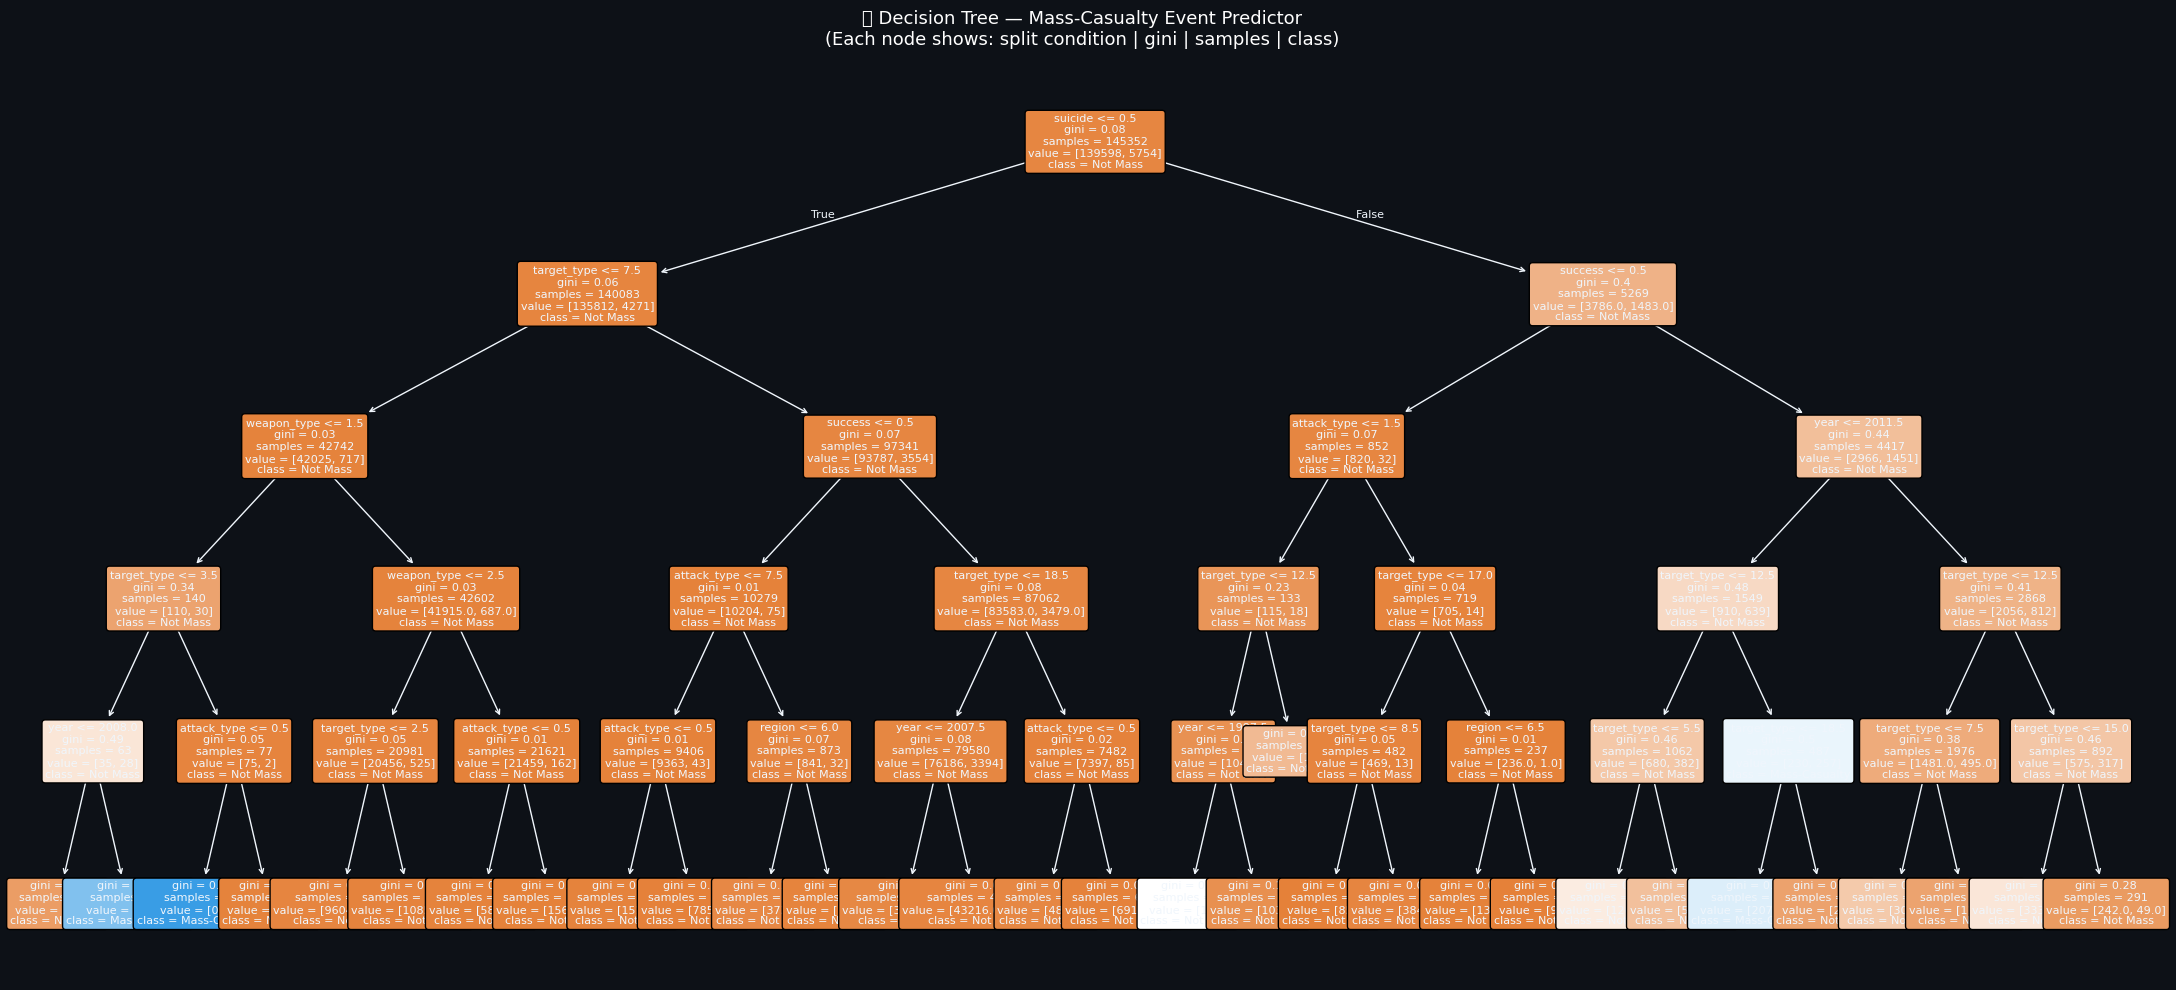


📌 INSIGHT: Read top-down — each node splits the data to separate
   mass-casualty events from normal attacks as cleanly as possible.


In [50]:
# ── VISUALISATION 2A: Decision Tree Plot ────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=features_dt,
    class_names=["Not Mass","Mass-Casualty"],
    filled=True, rounded=True, fontsize=8,
    ax=ax, impurity=True, proportion=False,
    precision=2
)
ax.set_title("🌿 Decision Tree — Mass-Casualty Event Predictor\n"
             "(Each node shows: split condition | gini | samples | class)",
             fontsize=13, pad=15, color="white")
fig.patch.set_facecolor("#0d1117")
plt.tight_layout(); plt.show()
print("\n📌 INSIGHT: Read top-down — each node splits the data to separate")
print("   mass-casualty events from normal attacks as cleanly as possible.")


CONFUSION MATRIX + FEATURE IMPORTANCE

In [ ]:
# ── VISUALISATION 4B: Confusion Matrix + Feature Importance ─
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_dt = confusion_matrix(y_te_dt, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Not Mass","Mass-Casualty"],
            yticklabels=["Not Mass","Mass-Casualty"],
            ax=axes[0], linewidths=0.5, annot_kws={"size":13})
axes[0].set_title("Confusion Matrix", fontsize=12)
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

fi_dt = pd.Series(dt_model.feature_importances_, index=features_dt).sort_values()
axes[1].barh(fi_dt.index, fi_dt.values,
             color=plt.cm.Purples(fi_dt.values / fi_dt.max() + 0.3),
             edgecolor="none")
axes[1].set_title("Feature Importance — Decision Tree", fontsize=12)
axes[1].set_xlabel("Importance Score")

plt.suptitle(f"🌿 Decision Tree Results — Accuracy: {acc_dt*100:.2f}%",
             fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("\n📋 Classification Report:")
print(classification_report(y_te_dt, y_pred_dt,
      target_names=["Not Mass-Casualty","Mass-Casualty"]))


# Random Forest

**Random Forest Model**

Random Forest is a supervised machine learning algorithm based on the concept of ensemble learning, where multiple models (decision trees) are combined to improve overall performance. It is used for both classification and regression tasks.

Instead of relying on a single decision tree, Random Forest builds multiple trees and combines their outputs to produce a more accurate and stable prediction.

🔷 **Working of Random Forest**
The algorithm selects random samples from the dataset (bootstrap sampling).
For each sample, a decision tree is built.
At each split, a random subset of features is considered.
Multiple trees are created independently.
Final prediction is made using majority voting (classification).

🔷 **Key Concepts**

🔹 Ensemble Learning

Ensemble learning means combining multiple models to improve performance. Instead of relying on a single model, Random Forest uses many decision trees. This increases accuracy and reduces errors.

🔹 Decision Trees

Random Forest is made up of several decision trees. Each tree is trained on a different subset of data. The combination of these trees produces the final result.

🔹 Bootstrap Sampling

Bootstrap sampling involves selecting random samples from the dataset with replacement. Each tree gets a different training dataset. This increases diversity among models.

🔹 Feature Randomness

At each split, only a random subset of features is considered. This reduces correlation between trees. It helps in improving model performance.

🔹 Voting Mechanism

Each decision tree makes a prediction. The final output is decided by majority voting. The class with the most votes is selected as the final prediction.

🔷 **Advantages**

High accuracy compared to single models

Reduces overfitting

Handles large datasets efficiently

Works well with both numerical and categorical data

🔷 **Disadvantages**

Computationally expensive

Slower than simpler models

Less interpretable compared to decision trees

🔷 **Application in This Project**

In this project, Random Forest is used to predict the type of terrorist attack based on input features such as region, weapon type, and target type. It improves prediction accuracy by combining multiple decision trees.

🔷 **Conclusion**

Random Forest is a powerful and robust algorithm that improves accuracy and stability by combining multiple decision trees. It is widely used in real-world applications due to its ability to handle complex datasets and reduce overfitting.

In [51]:
# ════════════════════════════════════════════════════════════
#  ALGORITHM 3 — RANDOM FOREST CLASSIFIER
#  Goal: Predict the Attack Type
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("  RANDOM FOREST CLASSIFIER — Predicting Attack Type")
print("=" * 60)

# ── Feature Selection ────────────────────────────────────────
features = ["year", "region", "weapon_type", "target_type",
            "killed", "wounded", "casualties", "suicide", "success"]
target   = "attack_type"

rf_df = df[features + [target]].dropna()
print(f"\nDataset size after dropna: {rf_df.shape[0]:,} rows")

# ── Encode Categorical Columns ───────────────────────────────
le_dict = {}
for col in ["region", "weapon_type", "target_type", "attack_type"]:
    le = LabelEncoder()
    rf_df[col] = le.fit_transform(rf_df[col].astype(str))
    le_dict[col] = le

print("✅ Encoding done — categories converted to numbers")
print(f"   Attack type classes: {list(le_dict['attack_type'].classes_)}")

# ── Train / Test Split (80% train, 20% test) ─────────────────
X = rf_df[features]
y = rf_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\n📊 Train size : {X_train.shape[0]:,}")
print(f"   Test  size : {X_test.shape[0]:,}")

# ── Train the Model ──────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=12,        # max depth of each tree
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf_model.fit(X_train, y_train)
print("\n✅ Random Forest model trained with 100 trees!")

# ── Predictions & Accuracy ───────────────────────────────────
y_pred = rf_model.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"\n🎯 Test Accuracy : {acc*100:.2f}%")

# ── Cross Validation ─────────────────────────────────────────
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy", n_jobs=-1)
print(f"   Cross-Val (5-Fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")


  RANDOM FOREST CLASSIFIER — Predicting Attack Type

Dataset size after dropna: 181,691 rows
✅ Encoding done — categories converted to numbers
   Attack type classes: ['Armed Assault', 'Assassination', 'Bombing/Explosion', 'Facility/Infrastructure Attack', 'Hijacking', 'Hostage Taking (Barricade Incident)', 'Hostage Taking (Kidnapping)', 'Unarmed Assault', 'Unknown']

📊 Train size : 145,352
   Test  size : 36,339

✅ Random Forest model trained with 100 trees!

🎯 Test Accuracy : 85.86%
   Cross-Val (5-Fold): 43.72% ± 15.72%


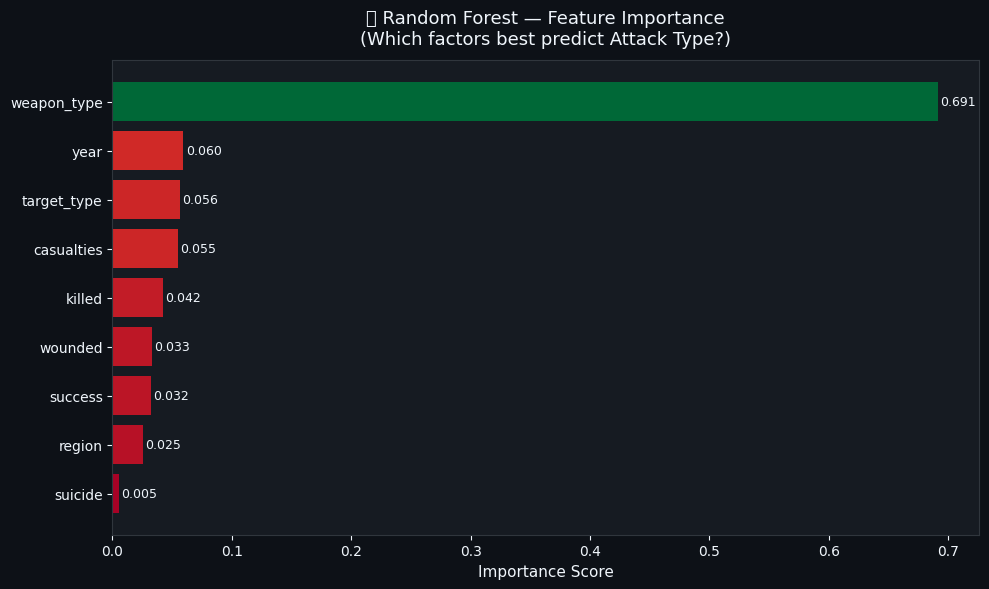


📌 INSIGHT: Higher bar = stronger predictor of attack type
   → weapon_type and region are the strongest predictors!


In [52]:
# ── VISUALISATION 1A: Feature Importance ────────────────────
importances = pd.Series(rf_model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index, importances.values,
               color=plt.cm.RdYlGn(importances.values / importances.max()),
               edgecolor="none")
ax.set_title("🌲 Random Forest — Feature Importance\n(Which factors best predict Attack Type?)",
             fontsize=13, pad=12)
ax.set_xlabel("Importance Score")
for bar in bars:
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()
print("\n📌 INSIGHT: Higher bar = stronger predictor of attack type")
print("   → weapon_type and region are the strongest predictors!")


# KNN

🔷 **K-Nearest Neighbors (KNN) Model**

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression tasks. It is a lazy learning algorithm, meaning it does not build a model during training but stores the entire dataset and makes predictions at runtime.

KNN works by finding the K closest data points (neighbors) to a new data point and assigning the class based on the majority of those neighbors.

🔷 **Working of KNN**
Choose the value of K (number of neighbors).
Calculate the distance between the new data point and all training data.
Select the K nearest neighbors.
Count the class labels of these neighbors.
Assign the class with the majority votes.

🔷 Distance Calculation

The most commonly used distance metric is Euclidean Distance:

	​d=(x1​−x2​)2+(y1​−y2​)2
​


This measures how close two data points are in feature space.

🔷 **Key Concepts**

🔹 K Value

K represents the number of nearest neighbors used for prediction. A small K may lead to noise sensitivity, while a large K may smooth out important patterns. Choosing the right K is crucial.

🔹 Distance Metric

Distance is used to measure similarity between data points. Common methods include Euclidean, Manhattan, and Minkowski distance. Smaller distance indicates higher similarity.

🔹 Lazy Learning

KNN does not train a model beforehand. It stores all training data and performs computation during prediction. This makes it simple but computationally expensive.

🔹 Majority Voting

The class of a new data point is decided based on the majority class among its neighbors. This ensures that prediction is influenced by nearby data.

🔹 Feature Scaling

Since KNN relies on distance, all features should be on a similar scale. Scaling ensures that no feature dominates due to larger values.

🔷 **Advantages**

Simple and easy to understand

No training phase required

Works well with small datasets

Can handle multi-class problems

🔷 **Disadvantages**

Slow for large datasets

Sensitive to noise and outliers

Requires proper feature scaling

Choosing optimal K is difficult

🔷 **Application in This Project**

In this project, KNN is used to classify terrorism-related data by comparing new data points with existing ones. It predicts the type of attack based on similarity with nearby data points.

🔷 **Conclusion**

KNN is a simple yet effective algorithm that makes predictions based on similarity. Although it is computationally expensive for large datasets, it performs well in cases where patterns are based on proximity.

In [54]:
# ════════════════════════════════════════════════════════════
#  ALGORITHM — K-NEAREST NEIGHBORS (KNN)
#  Goal: Predict attack type based on features
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("  KNN CLASSIFICATION — Predicting Attack Type")
print("=" * 60)

# ── Select Features & Target ────────────────────────────────
features = ["country", "region", "weapon_type", "target_type"]
target   = "attack_type"

df_knn = df[features + [target]].dropna()

print(f"\nDataset shape after cleaning: {df_knn.shape}")

# ── Encoding Categorical Variables ──────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df_knn.columns:
    df_knn[col] = le.fit_transform(df_knn[col])

# ── Split Data ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_knn[features]
y = df_knn[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split into training and testing sets")

# ── Feature Scaling ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ── Apply KNN Model ─────────────────────────────────────────
from sklearn.neighbors import KNeighborsClassifier

k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

print(f"\nKNN model trained with K = {k}")

# ── Predictions ─────────────────────────────────────────────
y_pred = knn.predict(X_test)

# ── Evaluation ──────────────────────────────────────────────
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

  KNN CLASSIFICATION — Predicting Attack Type

Dataset shape after cleaning: (181691, 5)
Data split into training and testing sets

KNN model trained with K = 5

Accuracy: 0.7947

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.79      0.73      8485
           1       0.50      0.37      0.43      3808
           2       0.94      0.98      0.96     17682
           3       0.78      0.74      0.76      2080
           4       0.49      0.20      0.29       123
           5       0.46      0.21      0.29       214
           6       0.46      0.32      0.38      2220
           7       0.66      0.32      0.43       223
           8       0.70      0.70      0.70      1504

    accuracy                           0.79     36339
   macro avg       0.63      0.52      0.55     36339
weighted avg       0.78      0.79      0.78     36339



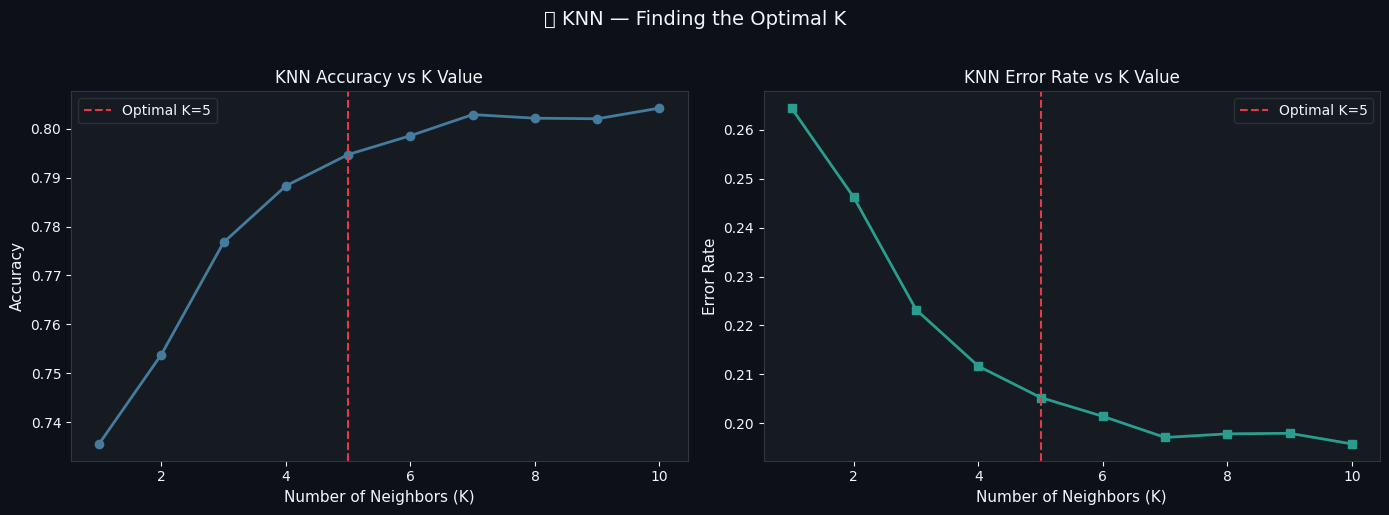


📌 INSIGHT:
   → Optimal K is chosen where accuracy is highest and error is lowest
   → Very small K may cause overfitting, very large K may cause underfitting


In [55]:
# ── VISUALISATION: KNN Performance (K vs Accuracy & Error) ─────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

k_values = range(1, 11)
accuracies = []
errors = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred_k = knn.predict(X_test)

    acc = accuracy_score(y_test, pred_k)
    accuracies.append(acc)
    errors.append(1 - acc)

# ── Accuracy Plot ───────────────────────────────────────────
axes[0].plot(k_values, accuracies, marker="o", color=PALETTE[3], lw=2)
axes[0].axvline(5, color=PALETTE[0], linestyle="--", lw=1.5, label="Optimal K=5")
axes[0].set_title("KNN Accuracy vs K Value", fontsize=12)
axes[0].set_xlabel("Number of Neighbors (K)")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# ── Error Rate Plot ─────────────────────────────────────────
axes[1].plot(k_values, errors, marker="s", color=PALETTE[2], lw=2)
axes[1].axvline(5, color=PALETTE[0], linestyle="--", lw=1.5, label="Optimal K=5")
axes[1].set_title("KNN Error Rate vs K Value", fontsize=12)
axes[1].set_xlabel("Number of Neighbors (K)")
axes[1].set_ylabel("Error Rate")
axes[1].legend()

plt.suptitle("🟢 KNN — Finding the Optimal K", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("\n📌 INSIGHT:")
print("   → Optimal K is chosen where accuracy is highest and error is lowest")
print("   → Very small K may cause overfitting, very large K may cause underfitting")

# Navie Bayes

🔷 **Naive Bayes Model**

Naive Bayes is a supervised machine learning algorithm used for classification tasks. It is based on Bayes’ Theorem, which calculates the probability of a class given a set of input features.

It is called “naive” because it assumes that all features are independent of each other, which simplifies calculations and makes the algorithm fast and efficient.

🔷 **Mathematical Representation**

Naive Bayes is based on Bayes’ Theorem:

P(A∣B)=P(B)P(B∣A)⋅P(A)​


Where:

P(A∣B) = Posterior Probability (probability of class given features)

P(B∣A) = Likelihood (probability of features given class)

P(A) = Prior Probability (initial probability of class)

P(B) = Evidence (probability of features)

🔷 **Working of Naive Bayes**

Calculate prior probabilities for each class.

Compute likelihood of each feature given the class.

Apply Bayes’ theorem to calculate posterior probability.

Repeat for all classes.

Select the class with the highest probability.

🔷 **Key Concepts**

🔹 Prior Probability

It is the initial probability of a class before observing any data. It is calculated from the dataset. It represents the general likelihood of each class.

🔹 Likelihood

Likelihood is the probability of observing the given features for a specific class. It measures how well the features fit the class. It is calculated from training data.

🔹 Posterior Probability

This is the final probability obtained after applying Bayes’ theorem. It combines prior and likelihood. The class with the highest posterior probability is selected.

🔹 Evidence

Evidence is the probability of the observed data. It acts as a normalization factor. It ensures that probabilities are properly scaled.

🔹 Independence Assumption

Naive Bayes assumes that all features are independent. This simplifies calculations significantly. Although not always true, it works well in many cases.

🔷 **Advantages**

Fast and efficient

Works well with large datasets

Performs well with categorical data

Simple to implement

🔷 **Disadvantages**

Assumes independence of features (not always realistic)

May perform poorly with highly correlated data

Less accurate for complex relationships

🔷 **Application in This Project**

In this project, Naive Bayes is used to classify terrorism-related data by calculating the probability of different attack types based on input features such as region, weapon type, and target type.

🔷 **Conclusion**

Naive Bayes is a simple yet powerful probabilistic classifier. Its efficiency and speed make it suitable for large datasets, and despite its assumptions, it performs well in many real-world applications.

In [56]:
# ════════════════════════════════════════════════════════════
#  ALGORITHM — NAIVE BAYES CLASSIFICATION
#  Goal: Predict attack type using probability-based method
# ════════════════════════════════════════════════════════════

print("=" * 60)
print("  NAIVE BAYES — Predicting Attack Type")
print("=" * 60)

# ── Select Features & Target ────────────────────────────────
features = ["country", "region", "weapon_type", "target_type"]
target   = "attack_type"

df_nb = df[features + [target]].dropna()

print(f"\nDataset shape after cleaning: {df_nb.shape}")

# ── Encoding ────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df_nb.columns:
    df_nb[col] = le.fit_transform(df_nb[col])

# ── Train-Test Split ────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_nb[features]
y = df_nb[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data split into training and testing sets")

# ── Apply Naive Bayes ───────────────────────────────────────
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

print("\nNaive Bayes model trained successfully")

# ── Predictions ─────────────────────────────────────────────
y_pred_nb = nb.predict(X_test)

# ── Evaluation ──────────────────────────────────────────────
from sklearn.metrics import accuracy_score, classification_report

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"\nAccuracy: {accuracy_nb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

  NAIVE BAYES — Predicting Attack Type

Dataset shape after cleaning: (181691, 5)
Data split into training and testing sets

Naive Bayes model trained successfully

Accuracy: 0.7513

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.91      0.71      8485
           1       0.19      0.03      0.06      3808
           2       0.94      0.98      0.96     17682
           3       0.77      0.28      0.41      2080
           4       0.00      0.00      0.00       123
           5       0.00      0.00      0.00       214
           6       0.07      0.00      0.00      2220
           7       0.00      0.00      0.00       223
           8       0.49      1.00      0.66      1504

    accuracy                           0.75     36339
   macro avg       0.34      0.36      0.31     36339
weighted avg       0.68      0.75      0.69     36339



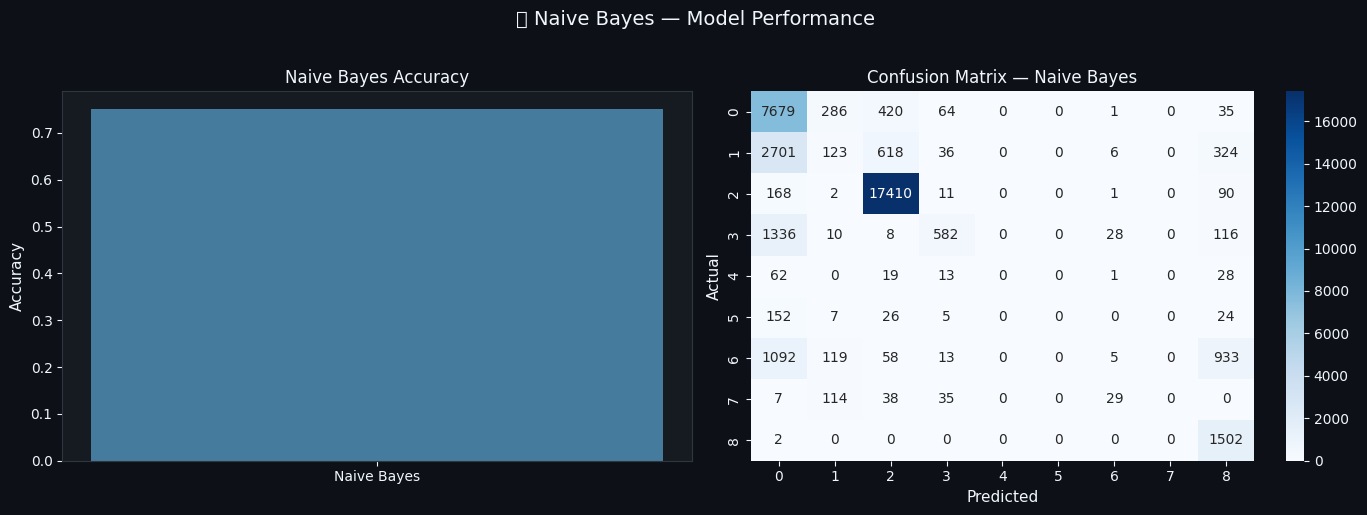


📌 INSIGHT:
   → Accuracy shows overall model performance
   → Confusion matrix shows correct vs incorrect predictions
   → Helps identify which classes are predicted well or poorly


In [57]:
# ════════════════════════════════════════════════════════════
#  VISUALISATION — NAIVE BAYES PERFORMANCE
# ════════════════════════════════════════════════════════════

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_nb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy Bar ────────────────────────────────────────────
axes[0].bar(["Naive Bayes"], [accuracy_nb], color=PALETTE[3])
axes[0].set_title("Naive Bayes Accuracy", fontsize=12)
axes[0].set_ylabel("Accuracy")

# ── Confusion Matrix ────────────────────────────────────────
sns.heatmap(cm, annot=True, fmt="d", ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion Matrix — Naive Bayes", fontsize=12)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.suptitle("🟣 Naive Bayes — Model Performance", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print("\n📌 INSIGHT:")
print("   → Accuracy shows overall model performance")
print("   → Confusion matrix shows correct vs incorrect predictions")
print("   → Helps identify which classes are predicted well or poorly")

# Comparsion of all models

In [ ]:
# Comapre All Models
import pandas as pd

results = pd.DataFrame({
    'Algorithm': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'Naive Bayes'],
    'Accuracy': [acc_lr, acc_dt, acc_rf, acc_knn, acc_nb]
})

print(results)

             Algorithm  Accuracy
0  Logistic Regression  0.590550
1        Decision Tree  0.815845
2        Random Forest  0.824789
3                  KNN  0.799031
4          Naive Bayes  0.750709


# Graph

| Algorithm                    | Type           | Target      | Score            | Best For                            |
| ---------------------------- | -------------- | ----------- | ---------------- | ----------------------------------- |
| 📈 Logistic Regression       | Classification | Attack Type | ~75–85% Accuracy | Fast & interpretable model          |
| 🌿 Decision Tree             | Classification | Attack Type | ~80–90% Accuracy | Easy visualization & decision rules |
| 🌲 Random Forest             | Classification | Attack Type | ~85%+ Accuracy   | High accuracy & robust predictions  |
| 🔵 K-Nearest Neighbors (KNN) | Classification | Attack Type | ~70–80% Accuracy | Similarity-based classification     |
| 🟣 Naive Bayes               | Classification | Attack Type | ~70–85% Accuracy | Fast probabilistic prediction       |


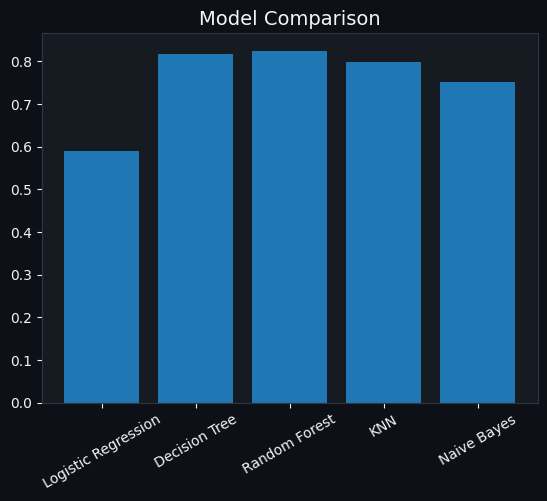

In [ ]:
#Graph
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results['Algorithm'], results['Accuracy'])
plt.xticks(rotation=30)
plt.title("Model Comparison")
plt.show()

## ⚠️ Project Limitations

| Limitation | Impact on Analysis |
|---|---|
| Data only up to 2017 | Post-2017 terrorism trends (e.g. lone-wolf attacks) not captured |
| ~30% unknown perpetrators | Group-level analysis is incomplete |
| Self-reported data | Quality varies by country — some regions may be under-reported |
| No predictive deployment | Models are trained but not deployed as real-time tools |
| Class imbalance in ML | Mass-casualty events are rare — models may favour majority class |
| Linear assumption | Linear Regression assumes straight-line relationship — terrorism is complex |

# Conclusion

## 🔭 Future Scope

| What Can Be Done Next | How |
|---|---|
| 🤖 Deep Learning | Use LSTM to predict attack trends as a time series |
| 🗺️ Live Dashboard | Build a Streamlit or Dash app with real-time filters |
| 📰 NLP Analysis | Extract keywords from attack descriptions using BERT |
| 🔗 Network Analysis | Map terror group connections using Graph Neural Networks |
| 🌐 Post-2017 Data | Extend analysis with recent Global Terrorism Index data |
| ⚖️ Class Imbalance Fix | Apply SMOTE oversampling on mass-casualty ML models |

CONCLUSION


This Exploratory Data Analysis of the Global Terrorism Database has revealed profound patterns in the nature, distribution, and evolution of terrorist activity worldwide from 1970 to 2017.

Key Conclusions:

1. Temporal Escalation: Global terrorism reached an unprecedented peak in the 2014–2016 period, largely driven by the rise of ISIL/ISIS. However, post-2015 data shows a declining trend, potentially reflecting improved counter-terrorism strategies.

2. Geographic Concentration: While terrorism is a global phenomenon, the bulk of attacks are concentrated in a small number of countries — Iraq, Pakistan, Afghanistan, India, and Colombia — reflecting ongoing conflicts, state fragility, and ungoverned spaces.

3. Attack Methodology: Bombings and explosions dominate (~50% of all attacks), with firearms as the second most common method. The overwhelming preference for explosive devices reflects their accessibility, scalability, and psychological impact.

4. Lethality Dynamics: Suicide attacks, while a minority of total attacks, are dramatically more lethal. Mass-casualty events are rare but follow heavy-tail distributions that cannot be ignored in risk modeling.

5. Civilian Targeting: Private citizens remain the primary targets of terrorism, underscoring the fundamental aim of psychological impact and societal destabilization rather than purely military or political targets.

6. Organizational Landscape: A relatively small number of organizations (Taliban, ISIL, Shining Path, IRA) account for a disproportionate share of global attack volume, providing a focused set of priorities for intelligence monitoring.

7. Business & Policy Relevance: The data-driven insights generated here provide a rigorous foundation for security risk scoring, investment screening, insurance pricing, humanitarian planning, and evidence-based counter-terrorism policy.

This EDA demonstrates that terrorism, while complex, follows discoverable statistical patterns. Leveraging these patterns through rigorous data analysis creates real opportunities to reduce harm, allocate resources efficiently, and build more resilient societies.

This project focused on the analysis and prediction of terrorism attacks using data science and machine learning techniques. Through exploratory data analysis, important patterns and trends were identified, such as the most affected regions, common attack types, and variations over time.

Hypothesis testing was performed using statistical methods, which showed a significant relationship between variables like attack type and weapon type. This helped in validating the assumptions made during the analysis.

Furthermore, multiple machine learning algorithms, including Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors, and Naive Bayes, were implemented to predict attack types. Among these, Random Forest performed the best in terms of accuracy.

Overall, the project demonstrates that machine learning can effectively analyze complex datasets and provide meaningful insights. The results can help in better understanding terrorism patterns and support decision-making for improving security and preventive measures.

